In [1]:
import warnings
from contextlib import contextmanager
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import PIL.Image as _PILImage
import seaborn as sns
from scipy.stats import binom, binomtest, mannwhitneyu, norm, wilcoxon

In [2]:
warnings.filterwarnings("ignore")

NUC     = Path("data/results/mtf2_nucleation")
FIG     = Path("figures")                          # every product of this notebook
FRAME   = NUC / "nuc_cpgonly_spread_bins.tsv.gz"   # 1-kb bins, built upstream

PH  = ["G1", "S1", "S2", "S3", "S4", "G2"]                              # cell-cycle fractions
RTL = ["Early", "Mid-early", "Mid", "Late-mid", "Mid-late", "Late"]
RL  = [f"{s} RT" for s in RTL]

COVCOL   = "mc"              # summed H3K27me3 counts (6 fractions x 2 replicates), per 1-kb bin
CI_ALPHA = 0.05              # bands are the 95% CI of the median

FOLD_GATE  = 0.20
GATE_SCALE = "log2"          # "log2" (primary) or "linear"

STAGE_TIME = {"G1": 0.0, "S1": 0.2, "S2": 0.4, "S3": 0.6, "S4": 0.8, "G2": 1.0}
XT         = [STAGE_TIME[p] for p in PH]
XLOW, XHI  = -0.03, 1.03


def mwu_report(x, y, label=""):
    """Two-sided Mann-Whitney U of `x` vs `y`, with AUC / rank-biserial effect size."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    x = x[np.isfinite(x)];    y = y[np.isfinite(y)]
    n1, n2 = x.size, y.size
    U, p = mannwhitneyu(x, y, alternative="two-sided")      # U is for `x`; scipy tie-corrects the p
    auc = U / (n1 * n2)                                     # == P(X>Y) + 0.5 P(X=Y)

    # tie-corrected normal approximation, so a log10(p) survives underflow
    allv = np.concatenate([x, y])
    _, cnt = np.unique(allv, return_counts=True)
    n = n1 + n2
    tie = float((cnt ** 3 - cnt).sum())
    sd = np.sqrt(n1 * n2 / 12.0 * ((n + 1) - tie / (n * (n - 1.0))))
    z = (U - n1 * n2 / 2.0) / sd if sd > 0 else np.nan
    log10p = float((norm.logsf(abs(z)) + np.log(2.0)) / np.log(10.0)) if np.isfinite(z) else np.nan

    stars = ("****" if p < 1e-4 else "***" if p < 1e-3 else
             "**" if p < 1e-2 else "*" if p < 0.05 else "ns")
    return dict(label=label, n1=n1, n2=n2, U=float(U), p=float(p), log10p=log10p, z=float(z),
                auc=float(auc), rb=float(2 * auc - 1), stars=stars)


def holm(pvals):
    """Holm-Bonferroni adjusted p-values (step-down), order preserved."""
    p = np.asarray(pvals, float); m = p.size
    order = np.argsort(p); adj = np.empty(m, float); run = 0.0
    for i, idx in enumerate(order):
        run = max(run, (m - i) * p[idx])
        adj[idx] = min(1.0, run)
    return adj


def effect_gate(fold, gate=FOLD_GATE, scale=GATE_SCALE):
    """Effect-size verdict for a median ratio `fold` (nucleation / other class)."""
    l2, lin = float(np.log2(fold)), float(fold - 1.0)
    e = dict(fold=float(fold), log2_fold=l2, linear_fold_diff=lin, gate=float(gate),
             gate_scale=scale, passes_log2=bool(abs(l2) >= gate),
             passes_linear=bool(abs(lin) >= gate))
    e["passes"] = e["passes_log2"] if scale == "log2" else e["passes_linear"]
    e["scales_disagree"] = bool(e["passes_log2"] != e["passes_linear"])
    e["margin_log2"] = abs(l2) - gate          # >0 clears the gate, <0 fails it, on the log2 scale
    return e


def gated_call(p_adj, fold, gate=FOLD_GATE, scale=GATE_SCALE):
    """(stars, effect-dict, is_significant); 'ns(fx)' = p passed but the effect gate did not."""
    e  = effect_gate(fold, gate, scale)
    st = ("****" if p_adj < 1e-4 else "***" if p_adj < 1e-3 else
          "**" if p_adj < 1e-2 else "*" if p_adj < 0.05 else "ns")
    if st == "ns":
        return "ns", e, False
    if not e["passes"]:
        return "ns(fx)", e, False
    return st, e, True


def fmt_p(r):
    """'p = 3.2e-51' when representable, else 'p ~ 1e-402' from the normal approximation."""
    return f"p = {r['p']:.2g}" if r["p"] > 0 else f"p ~ 1e{r['log10p']:.0f}"


def median_ci(V, alpha=CI_ALPHA):
    """Median and its distribution-free 95% CI (binomial order statistic), per column of `V`."""
    V   = np.asarray(V, dtype=float)
    med = np.nanmedian(V, axis=0)
    lo  = np.full(V.shape[1], np.nan)
    hi  = np.full(V.shape[1], np.nan)
    for j in range(V.shape[1]):
        v = np.sort(V[:, j][np.isfinite(V[:, j])])
        n = v.size
        if n < 6:
            continue
        k = int(binom.ppf(alpha / 2, n, 0.5))
        if k < 1:
            continue
        lo[j], hi[j] = v[k - 1], v[n - k]
    return med, lo, hi


CLR = {"nuc": "#C73131", "spr": "#3773b8", "cpg": "#E08214", "sprall": "#7B3FA0",
       "match": "#7B3FA0"}
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "pdf.fonttype": 42, "ps.fonttype": 42,
                     "svg.fonttype": "none", "font.family": "sans-serif",
                     "font.sans-serif": ["Helvetica", "Arial", "Liberation Sans", "DejaVu Sans"],
                     "axes.grid": False})

# RT bins: six equal intervals over the 2nd-98th percentile of the coding-gene RT distribution,
# shared with 260803_WT_timeseries_clean_chromHMM_pub.ipynb so the two notebooks' RT columns match.
RT_EDGES = np.array([0.16605208, 0.27145242, 0.37685275, 0.48225309, 0.58765342,
                     0.69305376, 0.79845409])

# the edges are hardcoded, so the derivation becomes the guard: if the gene source moves, this fires
RT_GENE_TSV = Path("data/2024/LAD_data/"
                   "JG_coding_genes_maxRPKM.tsv")
_rtg = pd.read_csv(RT_GENE_TSV, sep="\t")["RT"].dropna().to_numpy(float)
assert len(_rtg) == 19849, f"gene RT source changed: {len(_rtg)} finite-RT genes, expected 19,849"
assert np.allclose(RT_EDGES, np.linspace(np.quantile(_rtg, 0.02), np.quantile(_rtg, 0.98), num=7),
                   rtol=0, atol=1e-8), "the hardcoded RT edges are no longer the gene q02-q98 grid"

RT_EDGES_OPEN = RT_EDGES.copy(); RT_EDGES_OPEN[0], RT_EDGES_OPEN[-1] = 0.0, 1.0


def gene_rt_bin(RTraw, label=""):
    """RT bin 0-5 from raw RepliSeq, on the hardcoded edges. Out-of-range is clipped and reported.

    RT = 1 - clip(RepliSeq/100, 0, 1). The clip is symmetric, so negative RepliSeq (which the me2
    domain universe of section 9 does reach, giving RT > 1) is handled where RepliSeq > 100 is,
    rather than falling out of the binning as NaN.
    """
    rs = np.asarray(RTraw, float)
    rt = 1.0 - np.clip(rs / 100.0, 0.0, 1.0)
    b  = pd.cut(rt, bins=RT_EDGES, labels=False, include_lowest=True).astype(float)
    lo, hi = int((rt < RT_EDGES[0]).sum()), int((rt > RT_EDGES[-1]).sum())
    b  = np.where(rt < RT_EDGES[0], 0, np.where(rt > RT_EDGES[-1], 5, b))
    assert not np.isnan(b).any(), f"{label}: {int(np.isnan(b).sum())} bins still unassigned"
    print(f"  [RT bins] {label}: {len(rs):,} bins; out of range CLIPPED -> "
          f"{lo:,} below {RT_EDGES[0]:.8f} into Early, {hi:,} above {RT_EDGES[-1]:.8f} into Late "
          f"({int((rs > 100).sum()):,} had RepliSeq > 100, {int((rs < 0).sum()):,} had RepliSeq < 0)")
    return b.astype(int)

RT_BIN_SCHEME = ("gene-derived fixed edges (2nd-98th pct of coding-gene RT, 6 equal intervals; "
                 "shared with 260803_WT_timeseries_clean_chromHMM_pub.ipynb)")


def load_frame():
    """Analysis frame + per-bin max-scaled me3 trajectory (LM_*, the display scaling)."""
    D = pd.read_csv(FRAME, sep="\t")
    raw  = D[[f"me3_{p}" for p in PH]].to_numpy(float)
    posr = np.where(raw > 0, raw, np.nan)
    mx   = np.nanmax(posr, axis=1)
    for i, ph in enumerate(PH):
        D[f"LM_{ph}"] = posr[:, i] / np.where(mx > 0, mx, np.nan)

    # the frame ships its own equal-count sextiles in `rt_bin`; they are replaced here so every
    # section of this notebook bins on the shared gene-derived edges
    D["RTgene"] = 1.0 - np.clip(D.RTraw.to_numpy(float) / 100.0, 0.0, 1.0)
    D["rt_bin"] = gene_rt_bin(D.RTraw, "chromHMM frame (sections 1-8)")

    # the null archives were built on the opened-edge form of this binning; hardcoding the closed
    # edges is only safe because the two assign identically
    _open = pd.cut(D.RTgene, bins=RT_EDGES_OPEN, labels=False, include_lowest=True)
    assert int(_open.isna().sum()) == 0 and np.array_equal(D.rt_bin.to_numpy(), _open.to_numpy()), \
        "the hardcoded closed edges do not reproduce the opened-edge assignment the nulls were run on"
    return D


D   = load_frame()
LMC = [f"LM_{ph}" for ph in PH]

print(f"RT binning (all sections): {RT_BIN_SCHEME}")
print(f"  edges: {', '.join(f'{e:.6f}' for e in RT_EDGES)}")
print(f"  {'RT bin':<12} {'n bins':>9} {'n spreading':>12} {'n nucleation':>13}")
for _b in range(6):
    _m = D.rt_bin == _b
    print(f"  {RL[_b]:<12} {int(_m.sum()):>9,} "
          f"{int((_m & (D.cls == 'spread')).sum()):>12,} "
          f"{int((_m & (D.cls == 'nuc')).sum()):>13,}")

  [RT bins] chromHMM frame (sections 1-8): 172,864 bins; out of range CLIPPED -> 82 below 0.16605208 into Early, 104 above 0.79845409 into Late (0 had RepliSeq > 100, 0 had RepliSeq < 0)
RT binning (all sections): gene-derived fixed edges (2nd-98th pct of coding-gene RT, 6 equal intervals; shared with 260803_WT_timeseries_clean_chromHMM_pub.ipynb)
  edges: 0.166052, 0.271452, 0.376853, 0.482253, 0.587653, 0.693054, 0.798454
  RT bin          n bins  n spreading  n nucleation
  Early RT        13,875       12,745           649
  Mid-early RT    54,756       51,767         1,687
  Mid RT          56,120       53,689         1,172
  Late-mid RT     32,469       30,853           722
  Mid-late RT     13,522       12,811           250
  Late RT          2,122        1,949            44


# Polycomb machinery and H3K27 methylation by site class

In [3]:
SWARM_ORDER = ["nuc", "cpgonly", "spread"]
SWARM_LAB   = {"nuc": "Nucleation", "cpgonly": "CpG-only", "spread": "Spreading"}
SWARM_CLR   = {"nuc": "#C73131", "cpgonly": "#E08214", "spread": "#3773b8"}

# the level axis: per bin, max over the 6 fractions of the 2-replicate-mean RPKM
_R = D[[f"me3_{p}" for p in PH]].to_numpy(float)
assert np.isfinite(_R).all(), "non-finite RPKM in the frame"
D["maxrpkm"] = _R.max(axis=1)            # individual fractions may be 0; every per-bin max is > 0
assert (D.maxrpkm > 0).all()


def van_der_corput(n, base=2):
    """Generate n terms of a van der Corput sequence in [0, 1)."""
    seq = np.zeros(n, dtype=float)
    for i in range(n):
        x = i + 1  # start at 1 to avoid all zeros
        vdc = 0.0
        denom = 1.0
        while x > 0:
            x, remainder = divmod(x, base)
            denom *= base
            vdc += remainder / denom
        seq[i] = vdc
    return seq


def quasirandom_offsets(y, width=0.4, nbins=None):
    """Horizontal offsets for points `y`, ggbeeswarm::geom_quasirandom-style."""
    y = np.asarray(y, dtype=float)
    offsets = np.zeros_like(y, dtype=float)
    mask = ~np.isnan(y)
    y_valid = y[mask]
    if y_valid.size == 0:
        return offsets

    n = y_valid.size
    if nbins is None:
        nbins = max(5, int(round(np.sqrt(n))))
    ymin, ymax = y_valid.min(), y_valid.max()
    if ymin == ymax:                      # all points at one y -> spread over the full width
        seq = van_der_corput(n) - 0.5
        offsets[mask] = seq * width
        return offsets

    edges = np.linspace(ymin, ymax, nbins + 1)
    bin_idx = np.clip(np.digitize(y_valid, edges) - 1, 0, nbins - 1)

    counts = np.bincount(bin_idx, minlength=nbins)          # scale width by relative bin density
    bin_halfwidths = (width / 2.0) * (counts / counts.max())

    offsets_valid = np.zeros_like(y_valid, dtype=float)
    for b in range(nbins):
        idx = np.where(bin_idx == b)[0]
        if idx.size == 0 or bin_halfwidths[b] == 0.0:
            continue
        seq = van_der_corput(idx.size) - 0.5
        offsets_valid[idx] = seq * (2.0 * bin_halfwidths[b])

    offsets[mask] = offsets_valid
    return offsets


def geom_quasirandom_h(ax, data, y_col, x_col, order=None, width=0.4, nbins=None,
                       colors=None, alpha=0.7, size=10, **scatter_kwargs):
    """geom_quasirandom with the axes flipped: categories on y, values on x."""
    if order is None:
        order = list(dict.fromkeys(data[y_col]))
    y_positions = np.arange(len(order))
    for i, cat in enumerate(order):
        sub = data.loc[data[y_col] == cat, x_col].dropna()
        if sub.empty:
            continue
        vals = sub.values
        dy = quasirandom_offsets(vals, width=width, nbins=nbins)
        y_base = np.full_like(vals, y_positions[i], dtype=float)
        color = colors[i] if (colors is not None and i < len(colors)) else None
        ax.scatter(vals, y_base + dy, alpha=alpha, s=size, color=color,
                   edgecolors="none", **scatter_kwargs)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(order)


@contextmanager
def _pdf_no_indexed_images():
    """Make matplotlib's PDF backend keep rasterized RGB layers as 8-bit /DeviceRGB."""
    _orig = _PILImage.Image.getcolors
    _PILImage.Image.getcolors = lambda self, *a, **k: None
    try:
        yield
    finally:
        _PILImage.Image.getcolors = _orig


def save_illustrator_safe(fig, stem, dpi_png=200, dpi_pdf=600):
    """Save <stem>.png and <stem>.pdf, the PDF with a rasterized 8-bit-RGB point layer."""
    stem = Path(stem)
    fig.savefig(stem.with_suffix(".png"), bbox_inches="tight", dpi=dpi_png)
    with _pdf_no_indexed_images():
        fig.savefig(stem.with_suffix(".pdf"), bbox_inches="tight", dpi=dpi_pdf)

    raw = stem.with_suffix(".pdf").read_bytes()
    assert raw.count(b"/Subtype /Image") > 0, f"{stem.name}.pdf carries no raster image"
    assert b"/Indexed" not in raw, f"{stem.name}.pdf still carries an /Indexed image"
    assert b"/DeviceRGB" in raw, f"{stem.name}.pdf has no DeviceRGB raster"


def _rt_strip(fig, gs, b, frame=None, row=1):
    """RT box strip (YlGn, coloured by this bin's median RT) under column `b`."""
    fr     = D if frame is None else frame
    ax2    = fig.add_subplot(gs[row, b])
    subset = fr.loc[fr.rt_bin == b, "RTo"].dropna()
    cmap   = plt.get_cmap("YlGn"); _rtnorm = mcolors.Normalize(vmin=0, vmax=1)
    sns.boxplot(x=subset.values, ax=ax2, color=cmap(_rtnorm(float(subset.median()))),
                fliersize=0, linewidth=1, linecolor="black", orient="h")
    ax2.set_xlim(XLOW, XHI)
    ax2.grid(axis="x", linestyle="--", color="lightgray", linewidth=0.7)
    ax2.set_xticks(XT); ax2.set_xticklabels("")
    ax2.set_yticks([])
    ax2.xaxis.tick_top(); ax2.tick_params(labelbottom=False, labeltop=False)
    ax2.set_ylabel("RT" if b == 0 else "", rotation=0, labelpad=20)
    for spine in ax2.spines.values():
        spine.set_edgecolor("black"); spine.set_linewidth(1)

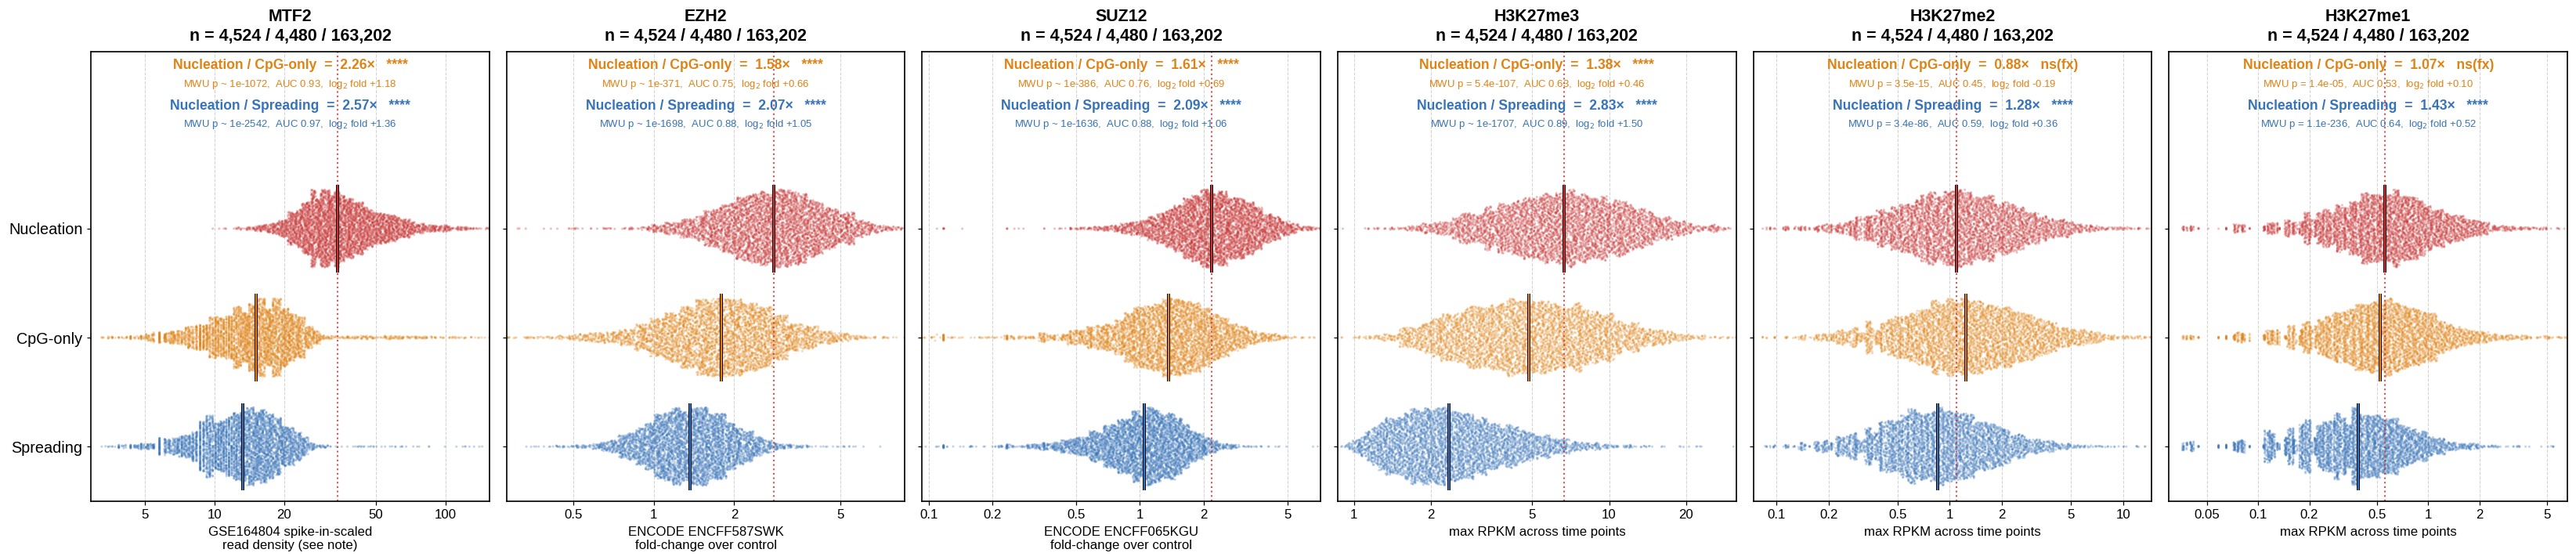

In [4]:
MATDIR  = NUC.parent / "replitag_sphase_nucleation/matrices"
COVFULL = NUC / "per_bin_covcorr_full.tsv.gz"

# me3 / me2 / me1 from the source matrix (2-replicate mean, per fraction)
_rp  = pd.read_csv(MATDIR / "encode_coremarks.1000bp.rpkm.matrix.tsv.gz", sep="\t").set_index("bin_id")
_sub = _rp.loc[D.bin_id]
for _mk, _out in [("K27me3", "me3"), ("K27me2", "me2"), ("K27me1", "me1")]:
    _M = np.stack([(_sub[f"{_mk}_{p}_a"].values + _sub[f"{_mk}_{p}_b"].values) / 2 for p in PH], 1)
    D[f"{_out}_maxrpkm"] = _M.max(axis=1)
# the me3 column must reproduce the beeswarm's `maxrpkm` exactly — the frame and the matrix agree
assert float(np.abs(D.me3_maxrpkm.values - D.maxrpkm.values).max()) < 1e-9

# max-scaled me2 / me1 trajectories (LMme2_*, LMme1_*), the display scaling
MARK_SPEC = [("K27me2", "me2", "H3K27me2"), ("K27me1", "me1", "H3K27me1")]
MARK_COLS = {}
for _mk, _pre, _lab in MARK_SPEC:
    _rawm = np.stack([(_sub[f"{_mk}_{p}_a"].values + _sub[f"{_mk}_{p}_b"].values) / 2 for p in PH], 1)
    _posm = np.where(_rawm > 0, _rawm, np.nan)
    _mxm  = np.nanmax(_posm, axis=1)
    _lmm  = _posm / np.where(_mxm > 0, _mxm, np.nan)[:, None]
    for _j, _p in enumerate(PH):
        D[f"{_pre}_{_p}"]   = _rawm[:, _j]
        D[f"LM{_pre}_{_p}"] = _lmm[:, _j]
    MARK_COLS[_lab] = ([f"LM{_pre}_{_p}" for _p in PH], [f"{_pre}_{_p}" for _p in PH])
MARK_TRAJ = {"H3K27me3": ([f"LM_{p}" for p in PH],    "me3"),
             "H3K27me2": ([f"LMme2_{p}" for p in PH], "me2"),
             "H3K27me1": ([f"LMme1_{p}" for p in PH], "me1")}
for _lab, (_cols, _pre) in MARK_TRAJ.items():
    assert all(c in D.columns for c in _cols), f"{_lab}: LM columns missing ({_cols[0]})"

_cv = pd.read_csv(COVFULL, sep="\t", usecols=["bin_id", "MTF2", "SUZ12", "EZH2"]).set_index("bin_id")
for _c in ["MTF2", "SUZ12", "EZH2"]:
    D[_c] = _cv[_c].reindex(D.bin_id).to_numpy()

try:
    import pyBigWig                       # optional: only this cross-check needs it
    _MD = Path("data/2024/MTF2_GSE164804")
    _BWCHK = {"EZH2":  _MD / "ENCODE_EZH2_K562_ENCFF587SWK_fc_hg38.bw",
              "SUZ12": _MD / "ENCODE_SUZ12_K562_ENCFF065KGU_fc_hg38.bw",
              "MTF2":  _MD / "MTF2_shCT_hg38_coverage.bw"}
    _chk = D.sample(6, random_state=0)
    for _k, _p in _BWCHK.items():
        _bw = pyBigWig.open(str(_p))
        _d = max(abs(_bw.stats(r["chr"], int(r.start), int(r.end), type="mean")[0] - r[_k])
                 for _, r in _chk.iterrows())
        _bw.close()
        assert _d < 1e-4, f"{_k} is not the bigWig bin mean (max|diff| = {_d:.3g})"
except (ImportError, RuntimeError, OSError):
    pass    # pyBigWig or the bigWigs absent -> cross-check skipped; the values used below
            # come from per_bin_covcorr_full.tsv.gz either way, so nothing else changes

MM_MARKS = [
    ("MTF2",        "MTF2",     "GSE164804 spike-in-scaled\nread density (see note)"),
    ("EZH2",        "EZH2",     "ENCODE ENCFF587SWK\nfold-change over control"),
    ("SUZ12",       "SUZ12",    "ENCODE ENCFF065KGU\nfold-change over control"),
    ("me3_maxrpkm", "H3K27me3", "max RPKM across time points"),
    ("me2_maxrpkm", "H3K27me2", "max RPKM across time points"),
    ("me1_maxrpkm", "H3K27me1", "max RPKM across time points"),
]

MM_SITE_SET = "measurable"                           # "measurable" | "common" | "per_mark"
assert MM_SITE_SET in {"measurable", "common", "per_mark"}

_FINITE = {lab: np.isfinite(D[col].to_numpy(float)) for col, lab, _ in MM_MARKS}
_AVAIL  = {lab: _FINITE[lab] & (D[col].to_numpy(float) > 0)      # finite AND drawable on a log axis
           for col, lab, _ in MM_MARKS}
MM_MEASURABLE = np.logical_and.reduce([_FINITE[lab] for _, lab, _ in MM_MARKS])
MM_COMMON     = np.logical_and.reduce([_AVAIL[lab]  for _, lab, _ in MM_MARKS])
MM_SITES      = {"measurable": MM_MEASURABLE, "common": MM_COMMON}.get(MM_SITE_SET)

# per-mark statistics on the selected site set
MM = {}
for col, lab, _ in MM_MARKS:
    v = D[col].to_numpy(float)
    ok = _AVAIL[lab] if MM_SITES is None else MM_SITES
    e = dict(col=col, ok=ok, avail=_AVAIL[lab],
             n={c: int(((D.cls == c) & ok).sum()) for c in SWARM_ORDER},
             n_avail={c: int(((D.cls == c).values & _AVAIL[lab]).sum()) for c in SWARM_ORDER},
             n_nan={c: int(((D.cls == c).values & ~np.isfinite(v)).sum()) for c in SWARM_ORDER},
             n_zero={c: int(((D.cls == c).values & np.isfinite(v) & (v <= 0)).sum())
                     for c in SWARM_ORDER},
             n_zero_in_set={c: int(((D.cls == c).values & ok & np.isfinite(v) & (v <= 0)).sum())
                            for c in SWARM_ORDER},
             n_all={c: int((D.cls == c).sum()) for c in SWARM_ORDER})
    e["med"] = {c: float(np.median(v[(D.cls == c).values & ok])) for c in SWARM_ORDER}
    e["fold"] = {c: e["med"]["nuc"] / e["med"][c] for c in SWARM_ORDER}
    e["dropped"] = {c: e["n_all"][c] - e["n"][c] for c in SWARM_ORDER}
    MM[lab] = e

MM_MWU = {}
for col, lab, _ in MM_MARKS:
    v, ok = D[col].to_numpy(float), MM[lab]["ok"]
    xs = v[(D.cls == "nuc").values & ok]
    MM_MWU[lab] = {c: mwu_report(xs, v[(D.cls == c).values & ok], f"{lab}: nuc vs {SWARM_LAB[c]}")
                   for c in ["cpgonly", "spread"]}
_keys = [(lab, c) for _, lab, _ in MM_MARKS for c in ["cpgonly", "spread"]]
for (lab, c), a in zip(_keys, holm([MM_MWU[lab][c]["p"] for lab, c in _keys])):
    MM_MWU[lab][c]["p_holm"] = float(a)

for _, lab, _ in MM_MARKS:
    for c in ["cpgonly", "spread"]:
        st, e, ok = gated_call(MM_MWU[lab][c]["p_holm"], MM[lab]["fold"][c])
        MM_MWU[lab][c].update(stars_gated=st, significant=ok,
                              **{f"gate_{k}": v for k, v in e.items()})

# figure: 1 row x 6 columns, deterministic per-mark display subsample
MM_SEED = 0
fig, axes = plt.subplots(1, len(MM_MARKS), figsize=(5.0 * len(MM_MARKS), 6.6), sharey=True)
YPOS = np.arange(len(SWARM_ORDER))

for ax, (col, lab, desc) in zip(np.atleast_1d(axes), MM_MARKS):
    e = MM[lab]
    nplot = min(e["n"].values())
    rng, parts = np.random.default_rng(MM_SEED), []
    for c in SWARM_ORDER:
        sub = D.loc[(D.cls == c).values & e["ok"], ["cls", col]]
        if len(sub) > nplot:
            sub = sub.iloc[np.sort(rng.choice(len(sub), nplot, replace=False))]
        parts.append(sub.rename(columns={col: "val"}))
    # zeros are not plotted (a log axis cannot place them); they remain in the
    # statistics and in this panel's n
    Sm = pd.concat(parts, ignore_index=True)
    _pos = Sm.val.to_numpy(float) > 0
    e["n_zero_not_drawn"] = int((~_pos).sum())
    e["n_drawn"] = int(_pos.sum())
    Sm = Sm.loc[_pos].reset_index(drop=True)
    Sm["log10val"] = np.log10(Sm.val)

    geom_quasirandom_h(ax, Sm, "cls", "log10val", order=SWARM_ORDER,
                       colors=[SWARM_CLR[c] for c in SWARM_ORDER],
                       width=0.72, alpha=0.30, size=4.0, rasterized=True)

    HW = 0.40
    for i, c in enumerate(SWARM_ORDER):
        x = np.log10(e["med"][c])
        ax.vlines(x, YPOS[i] - HW, YPOS[i] + HW, color="black", lw=2.6, zorder=6)
        ax.vlines(x, YPOS[i] - HW, YPOS[i] + HW, color=SWARM_CLR[c], lw=1.4, zorder=7)
    ax.axvline(np.log10(e["med"]["nuc"]), color=SWARM_CLR["nuc"], ls=":", lw=1.4, alpha=0.8, zorder=2)

    qlo, qhi = np.percentile(Sm.val.to_numpy(float), [0.5, 99.5])
    lo, hi   = float(np.log10(qlo)), float(np.log10(qhi))
    pad      = 0.06 * (hi - lo)
    e["n_outside"] = int(((Sm.val < qlo) | (Sm.val > qhi)).sum())
    e["xrange"]    = (float(qlo), float(qhi))
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(len(SWARM_ORDER) - 0.5, -1.62)         # inverted: nucleation on top, room for folds

    # nucleation-referenced folds, at the top of the column
    for _yy, _c, _nm in [(0.985, "cpgonly", "CpG-only"), (0.895, "spread", "Spreading")]:
        _r = MM_MWU[lab][_c]
        ax.text(0.5, _yy, f"Nucleation / {_nm}  =  {e['fold'][_c]:.2f}×   {_r['stars_gated']}",
                transform=ax.transAxes, ha="center", va="top", fontsize=11.5,
                color=SWARM_CLR[_c], fontweight="bold")
        ax.text(0.5, _yy - 0.043,
                f"MWU {fmt_p(_r)},  AUC {_r['auc']:.2f},  log$_2$ fold {_r['gate_log2_fold']:+.2f}",
                transform=ax.transAxes, ha="center", va="top", fontsize=8.6,
                color=SWARM_CLR[_c])

    # log x ticks
    dec = np.arange(np.floor(lo), np.ceil(hi) + 1)
    for mult in [(1, 2, 5), (1,)]:
        cand = np.sort(np.concatenate([10.0 ** dec * m for m in mult]))
        cand = cand[(cand >= 10 ** (lo - pad)) & (cand <= 10 ** (hi + pad))]
        if len(cand) <= 8:
            break
    if len(cand) > 8:
        cand = cand[::2]
    ax.set_xticks(np.log10(cand))
    ax.set_xticklabels([f"{t:g}" for t in cand], fontsize=11)
    ax.set_yticks(YPOS)
    ax.set_xlabel(desc, fontsize=11)
    ax.set_title(f"{lab}\nn = " + " / ".join(f"{e['n'][c]:,}" for c in SWARM_ORDER),
                 fontsize=14, fontweight="bold", pad=10)

    ax.grid(axis="x", color="lightgray", ls="--", lw=0.7, zorder=0); ax.set_axisbelow(True)
    for sp in ax.spines.values():
        sp.set_edgecolor("black"); sp.set_linewidth(1.1)

_ax0 = np.atleast_1d(axes)[0]
_ax0.set_yticks(YPOS)
_ax0.set_yticklabels([SWARM_LAB[c] for c in SWARM_ORDER], fontsize=13)
assert [t.get_text() for t in _ax0.get_yticklabels()] == [SWARM_LAB[c] for c in SWARM_ORDER]

fig.tight_layout()
save_illustrator_safe(fig, FIG / "fig_multimark_quasirandom_by_class")
plt.show()

# Nucleation v. Spreading line plot by H3K27me3 rank group

In [5]:
def med_ci(sub, cols=LMC):
    """Per-fraction median and its 95% CI across the bins in `sub`."""
    med, lo, hi = median_ci(sub[cols].to_numpy(float))
    return dict(med=med, lo=lo, hi=hi, n=len(sub), mc=float(np.median(sub[COVCOL])))


def top_n_spreading(mb, n, covcol=COVCOL):
    """The n spreading bins of highest `covcol` in this RT bin (ties broken by bin order)."""
    sp = mb[mb.cls == "spread"]
    if n > len(sp):                                     # never silently pad
        raise ValueError(f"only {len(sp)} spreading bins available, need {n}")
    return sp.sort_values(covcol, ascending=False, kind="stable").iloc[:n]


D["topN"] = False
RES = {}
for b in range(6):
    mb  = D[D.rt_bin == b]
    nuc = mb[mb.cls == "nuc"]                            # all nucleation bins   -> solid red arm
    cpg = mb[mb.cls == "cpgonly"]                        # all CpG-only bins     -> solid orange arm
    spr = mb[mb.cls == "spread"]                         # all spreading bins    -> dashed blue arm
    N   = len(nuc)
    top = top_n_spreading(mb, N)                         # top-N spreading by mc -> solid blue arm
    D.loc[top.index, "topN"] = True
    RES[b] = dict(N=N,
                  nuc_all=med_ci(nuc), cpg_all=med_ci(cpg), spr_topN=med_ci(top),
                  spr_all=med_ci(spr),
                  mc_nuc=float(np.median(nuc[COVCOL])), mc_cpg=float(np.median(cpg[COVCOL])),
                  mc_top=float(np.median(top[COVCOL])),
                  mc_spr_all=float(np.median(spr[COVCOL])),
                  mc_top_min=float(top[COVCOL].min()), mc_top_max=float(top[COVCOL].max()))

assert int(D.topN.sum()) == sum(RES[b]["N"] for b in range(6)), "topN flag lost bins"
assert (D.loc[D.topN, "cls"] == "spread").all(), "topN flag escaped the spreading class"

# tidy table: medians + 95% CI bounds for every arm
rows = []
for b in range(6):
    e = RES[b]
    for j, ph in enumerate(PH):
        row = dict(rt_bin=RL[b], fraction=ph, time=STAGE_TIME[ph],
                   band="CI95_of_median_binomial_order_statistic",
                   N_per_class=e["N"], n_cpgonly_all=e["cpg_all"]["n"],
                   n_spreading_pool=e["spr_all"]["n"],
                   mc_median_nucleation=e["mc_nuc"], mc_median_cpgonly=e["mc_cpg"],
                   mc_median_topN=e["mc_top"], mc_median_spreading_all=e["mc_spr_all"],
                   mc_fold_nuc_over_topN=e["mc_nuc"] / e["mc_top"],
                   mc_fold_nuc_over_all_spreading=e["mc_nuc"] / e["mc_spr_all"])
        for arm, pre in [("nuc_all", "nucleation_all"), ("cpg_all", "cpgonly_all"),
                         ("spr_topN", "spreading_topN"), ("spr_all", "spreading_all")]:
            row[pre] = e[arm]["med"][j]
            row[f"{pre}_ci95lo"] = e[arm]["lo"][j]
            row[f"{pre}_ci95hi"] = e[arm]["hi"][j]
        rows.append(row)
TRAJ = pd.DataFrame(rows)
TRAJ.to_csv(FIG / "me3_nuc_cpgonly_topN_spreading_CI95band.tsv", sep="\t", index=False)

  Late RT: 1,949 spreading sites (44 nucleation) — group sizes [0, 0, 949, 1000] vs the nominal [1000, 2000, 4000, 'rest']
    EMPTY, not drawn: Spreading rank 7,001+ (lowest H3K27me3)
    EMPTY, not drawn: Spreading rank 3,001-7,000 (n = 4,000)
    the top-1,000 group is 51% of this RT bin's ENTIRE spreading population (vs 8% or less in the bins that do fit), so it is a much weaker level restriction here and its panel is NOT equivalent to the others.


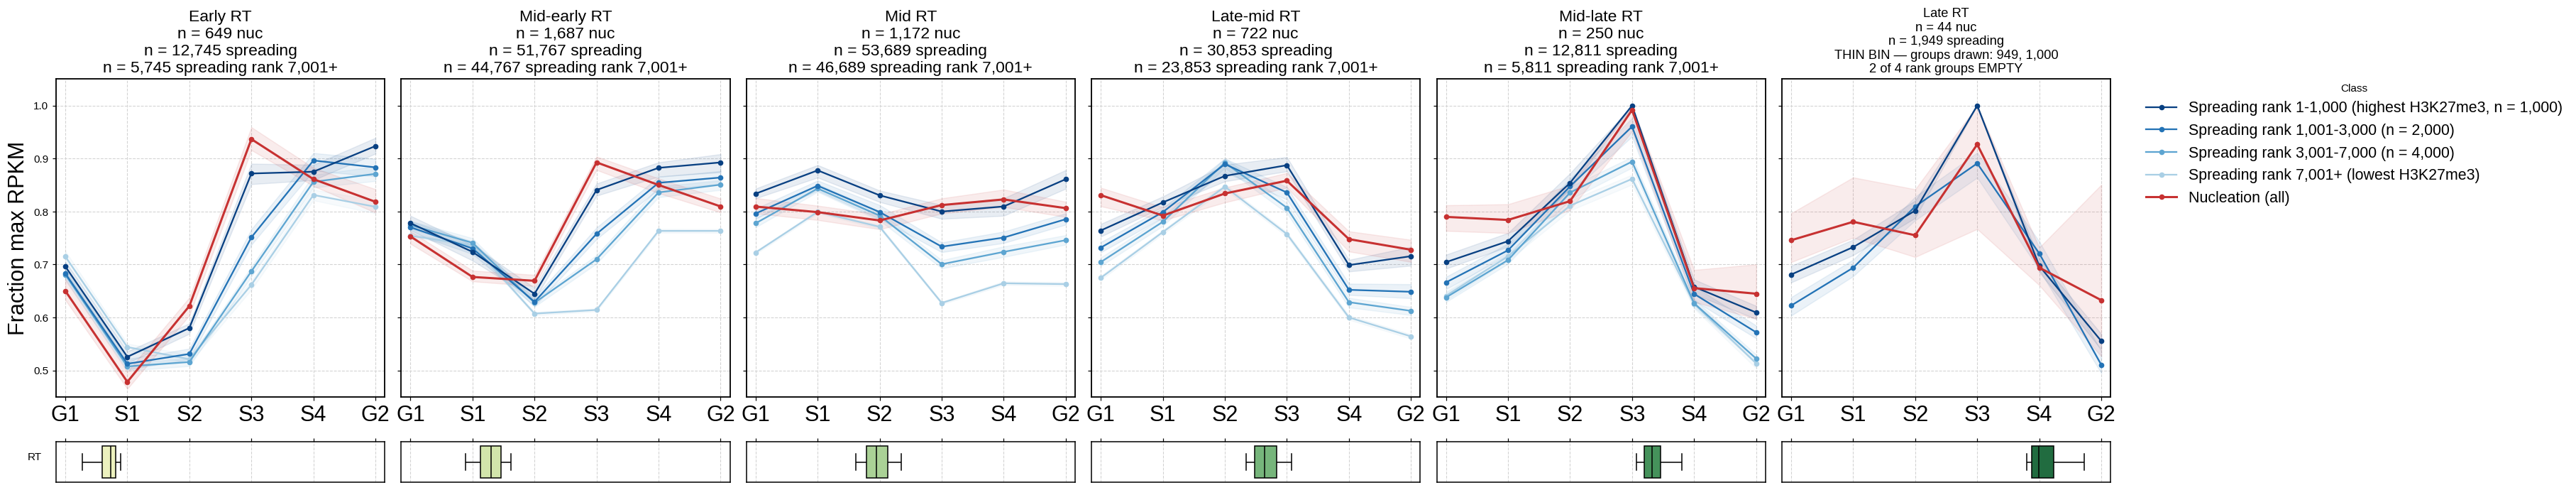

In [6]:
GN       = 4
LEVELCOL = "maxrpkm"        # per-bin max over the 6 fractions of the 2-replicate-mean me3 RPKM
GCUTS    = [1000, 3000, 7000]                            # descending-rank cut points
# groups are ordered lowest -> highest H3K27me3 so the Blues ramp runs light -> dark with level
GRANGE   = [(GCUTS[2] + 1, None), (GCUTS[1] + 1, GCUTS[2]), (GCUTS[0] + 1, GCUTS[1]), (1, GCUTS[0])]
GLAB     = ["Spreading rank 7,001+ (lowest H3K27me3)",
            "Spreading rank 3,001-7,000 (n = 4,000)",
            "Spreading rank 1,001-3,000 (n = 2,000)",
            "Spreading rank 1-1,000 (highest H3K27me3, n = 1,000)"]
GCLR     = [plt.get_cmap("Blues")(x) for x in (0.34, 0.54, 0.74, 0.94)]   # dark = highest H3K27me3
YLO, YHI = 0.45, 1.05       # fixed y-range, widened only if a CI band would fall outside it

TOP1K_GI = [i for i, (lo, hi) in enumerate(GRANGE) if (lo, hi) == (1, GCUTS[0])]
assert len(TOP1K_GI) == 1, "the rank-1-to-1,000 group is not uniquely identifiable in GRANGE"
TOP1K_GI = TOP1K_GI[0]
assert GLAB[TOP1K_GI].startswith("Spreading rank 1-1,000"), "TOP1K_GI points at the wrong group"
D["top1k"] = False

GTHIN = {}
GRES = {}
for b in range(6):
    mb  = D[D.rt_bin == b]
    nuc = mb[mb.cls == "nuc"]
    spr = mb[mb.cls == "spread"]
    rk  = spr[LEVELCOL].rank(method="first", ascending=False)     # rank 1 = highest H3K27me3
    gi  = [(rk >= lo) & (rk <= (len(spr) if hi is None else hi)) for lo, hi in GRANGE]
    assert sum(int(m.sum()) for m in gi) == len(spr), f"RT bin {b}: rank groups lost bins"
    if len(spr) <= GCUTS[-1]:
        GTHIN[b] = dict(n_spr=len(spr), n_nuc=len(nuc),
                        empty=[i for i in range(GN) if int(gi[i].sum()) == 0],
                        sizes=[int(m.sum()) for m in gi])
    D.loc[spr.index[gi[TOP1K_GI].to_numpy()], "top1k"] = True
    GRES[b] = dict(N=len(nuc), nuc=med_ci(nuc), n_spr=len(spr),
                   g=[med_ci(spr[m]) if int(m.sum()) else None for m in gi],
                   g_level=[float(np.median(spr.loc[m, LEVELCOL])) if int(m.sum()) else np.nan
                            for m in gi])

if GTHIN:
    print(f"WARNING: the {GCUTS[-1]:,}-deep rank ladder does not fit in "
          f"{len(GTHIN)} of 6 RT bins. Groups that could not be filled are SKIPPED, not padded:")
    for b, t in GTHIN.items():
        print(f"  {RL[b]}: {t['n_spr']:,} spreading sites ({t['n_nuc']:,} nucleation) — "
              f"group sizes {t['sizes']} vs the nominal "
              f"{[GCUTS[0], GCUTS[1] - GCUTS[0], GCUTS[2] - GCUTS[1], 'rest']}")
        for i in t["empty"]:
            print(f"    EMPTY, not drawn: {GLAB[i]}")
        print(f"    the top-1,000 group is {100 * GCUTS[0] / t['n_spr']:.0f}% of this RT bin's "
              f"ENTIRE spreading population (vs "
              f"{100 * GCUTS[0] / min(GRES[c]['n_spr'] for c in range(6) if c not in GTHIN):.0f}% "
              f"or less in the bins that do fit), so it is a much weaker level restriction here "
              f"and its panel is NOT equivalent to the others.")
else:
    print(f"the {GCUTS[-1]:,}-deep rank ladder fits in all 6 RT bins")

assert int(D.top1k.sum()) == 6 * GCUTS[0], "top1k flag lost bins"
assert (D.loc[D.top1k, "cls"] == "spread").all(), "top1k flag escaped the spreading class"
assert all(int((D.top1k & (D.rt_bin == b)).sum()) == GCUTS[0] for b in range(6)), \
    "top1k is not 1,000 per RT bin"

def _bands(b):
    """Every drawn band in RT bin `b` that actually has finite CI bounds."""
    return [e for e in [GRES[b]["nuc"]] + [g for g in GRES[b]["g"] if g is not None]
            if np.isfinite(e["lo"]).any() and np.isfinite(e["hi"]).any()]


_lo = min(float(np.nanmin(e["lo"])) for b in range(6) for e in _bands(b))
_hi = max(float(np.nanmax(e["hi"])) for b in range(6) for e in _bands(b))
GYLO = YLO if _lo >= YLO else _lo - 0.05 * (_hi - _lo)
GYHI = YHI if _hi <= YHI else _hi + 0.05 * (_hi - _lo)

fig = plt.figure(figsize=(28, 6))
gs  = fig.add_gridspec(2, 6, height_ratios=[5.5, 0.7], hspace=0.25)

for b in range(6):
    e  = GRES[b]
    ax = fig.add_subplot(gs[0, b])

    _drawn = [i for i in range(GN) if e["g"][i] is not None]   # skipped groups are absent, not NaN
    for i in _drawn:                                         # fills first, all lines on top of them
        ax.fill_between(XT, e["g"][i]["lo"], e["g"][i]["hi"], color=GCLR[i], alpha=0.09, zorder=2)
    ax.fill_between(XT, e["nuc"]["lo"], e["nuc"]["hi"], color=CLR["nuc"], alpha=0.09, zorder=2)
    for i in _drawn:
        ax.plot(XT, e["g"][i]["med"], label=GLAB[i], color=GCLR[i], linestyle="-", marker="o",
                markersize=4, linewidth=1.5, zorder=4)
    ax.plot(XT, e["nuc"]["med"], label="Nucleation (all)", color=CLR["nuc"], linestyle="-",
            marker="o", markersize=4, linewidth=2.0, zorder=5)

    ax.set_xlim(XLOW, XHI); ax.set_ylim(GYLO, GYHI)
    ax.set_xticks(XT); ax.set_xticklabels(PH, rotation=0, ha="center", fontsize=20)
    # the title states this panel's own group sizes; in a thin RT bin some of them are zero
    _t = f"{RL[b]}\nn = {e['N']:,} nuc\nn = {e['n_spr']:,} spreading"
    if b in GTHIN:
        _sizes = ", ".join(format(e["g"][i]["n"], ",") for i in _drawn)
        _t += (f"\nTHIN BIN — groups drawn: {_sizes}"
               f"\n{GN - len(_drawn)} of {GN} rank groups EMPTY")
    else:
        _t += f"\nn = {e['g'][0]['n']:,} spreading rank 7,001+"
    ax.set_title(_t, fontsize=15 if b not in GTHIN else 12)
    ax.grid(axis="both", color="lightgray", linestyle="--", linewidth=0.7)
    if b == 0:
        ax.set_ylabel("Fraction max RPKM", fontsize=20)
    else:
        ax.set_yticklabels([])
    for spine in ax.spines.values():
        spine.set_edgecolor("black"); spine.set_linewidth(1.2)

    _rt_strip(fig, gs, b)

# collected over all six axes: the thin RT bin is the last panel, so reading the legend off it
# would silently drop exactly the groups that bin could not fill
_seen = {}
for _ax in fig.axes:
    for _h, _l in zip(*_ax.get_legend_handles_labels()):
        _seen.setdefault(_l, _h)
_order = GLAB[::-1] + ["Nucleation (all)"]               # legend reads highest -> lowest H3K27me3
assert set(_seen) == set(_order), \
    f"legend lost a group across all panels: missing {sorted(set(_order) - set(_seen))}"
pairs  = sorted(_seen.items(), key=lambda x: _order.index(x[0]))
ls, hs = zip(*[(l, h) for l, h in pairs])
fig.legend(hs, ls, title="Class", bbox_to_anchor=(0.98, 0.95), loc="upper left",
           frameon=False, fontsize=14)

fig.subplots_adjust(left=0.03, right=0.97, top=0.93, bottom=0.07, wspace=0.05, hspace=0.1)

rows = []
for b in range(6):
    e = GRES[b]
    for j, ph in enumerate(PH):
        row = dict(rt_bin=RL[b], fraction=ph, time=STAGE_TIME[ph],
                   band="CI95_of_median_binomial_order_statistic",
                   value_scale="max_normalized_fraction_of_max_RPKM",
                   group_variable=LEVELCOL, group_scope="descending rank within RT bin",
                   group_rank_cuts="1000/3000/7000", n_spreading_pool=e["n_spr"],
                   rt_binning=RT_BIN_SCHEME,
                   rank_ladder_fits=bool(b not in GTHIN),
                   n_rank_groups_empty=(GN - sum(g is not None for g in e["g"])),
                   top1k_frac_of_spreading_pool=GCUTS[0] / e["n_spr"],
                   n_nucleation=e["N"], nucleation_all=e["nuc"]["med"][j],
                   nucleation_all_ci95lo=e["nuc"]["lo"][j],
                   nucleation_all_ci95hi=e["nuc"]["hi"][j])
        for i in range(GN):
            _lo_r, _hi_r = GRANGE[i]
            _hi_r = e["n_spr"] if _hi_r is None else _hi_r
            _g = e["g"][i]
            # a group this RT bin could not fill is written as n = 0 with NaN values, never as a
            # dropped column and never padded from a neighbouring bin
            row[f"rank_range_G{i+1}"]         = f"{_lo_r}-{_hi_r}"
            row[f"n_spreading_G{i+1}"]        = 0 if _g is None else _g["n"]
            row[f"median_me3_maxrpkm_G{i+1}"] = e["g_level"][i]
            row[f"spreading_G{i+1}"]          = np.nan if _g is None else _g["med"][j]
            row[f"spreading_G{i+1}_ci95lo"]   = np.nan if _g is None else _g["lo"][j]
            row[f"spreading_G{i+1}_ci95hi"]   = np.nan if _g is None else _g["hi"][j]
        rows.append(row)
pd.DataFrame(rows).to_csv(FIG / "me3_spreading_by_me3rank_CI95band.tsv", sep="\t", index=False)

GSTEM_R = "fig_me3_spreading_by_me3rank_CI95band"
for ext in ["pdf", "png"]:
    fig.savefig(FIG / f"{GSTEM_R}.{ext}", bbox_inches="tight",
                dpi=None if ext == "pdf" else 200)

assert GYLO <= _lo and GYHI >= _hi, "rank-group figure clips a CI band"
plt.show()

  Late RT: 1,949 spreading sites; 2 of 4 rank groups EMPTY, not drawn — Spreading rank 7,001+ (lowest H3K27me3); Spreading rank 3,001-7,000 (n = 4,000)
    the top-1,000 group is 51% of this RT bin's ENTIRE spreading population, so this panel is NOT equivalent to the others.


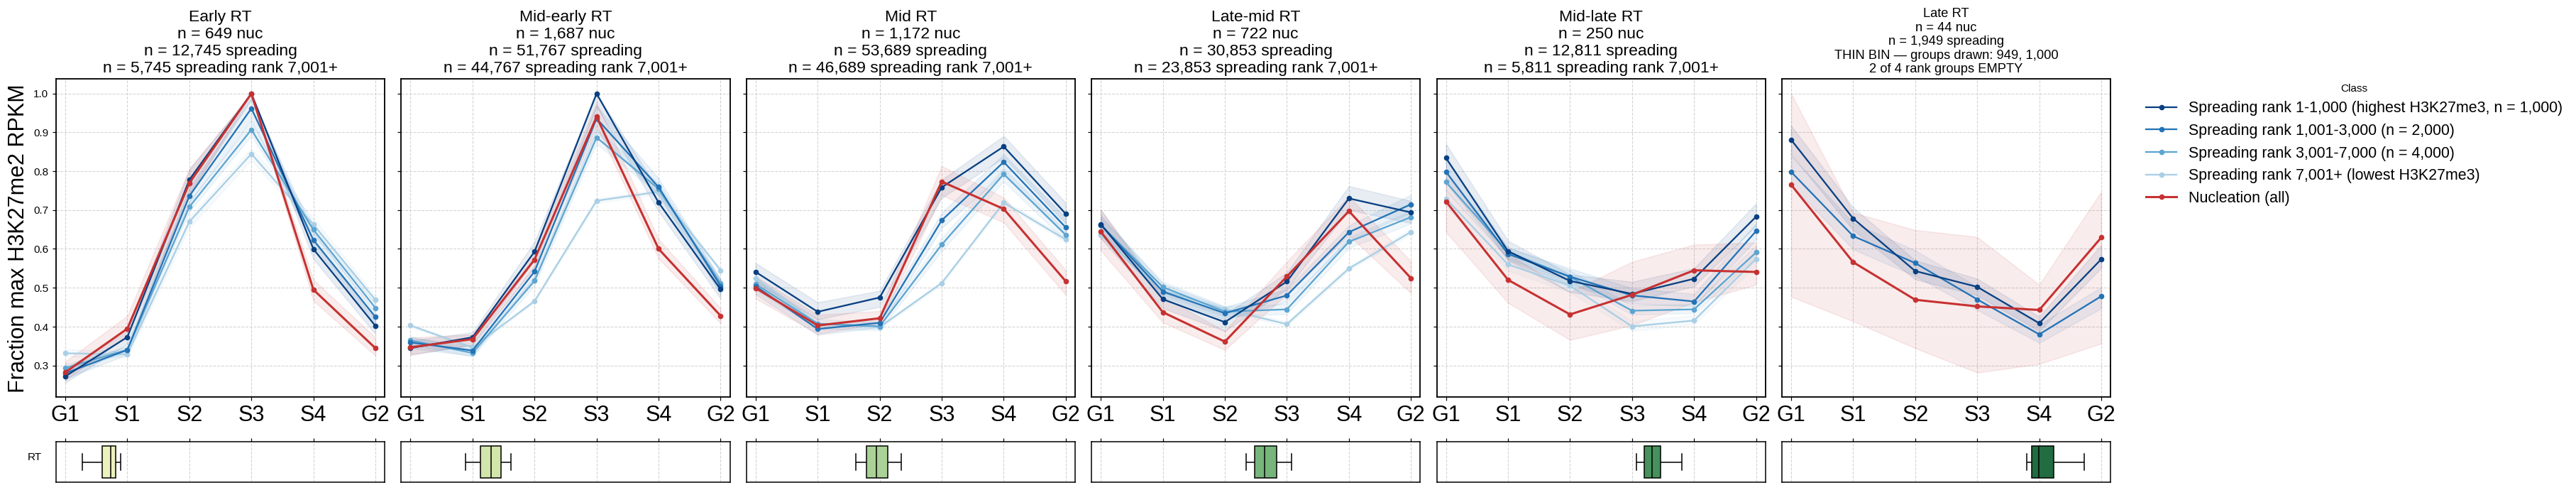

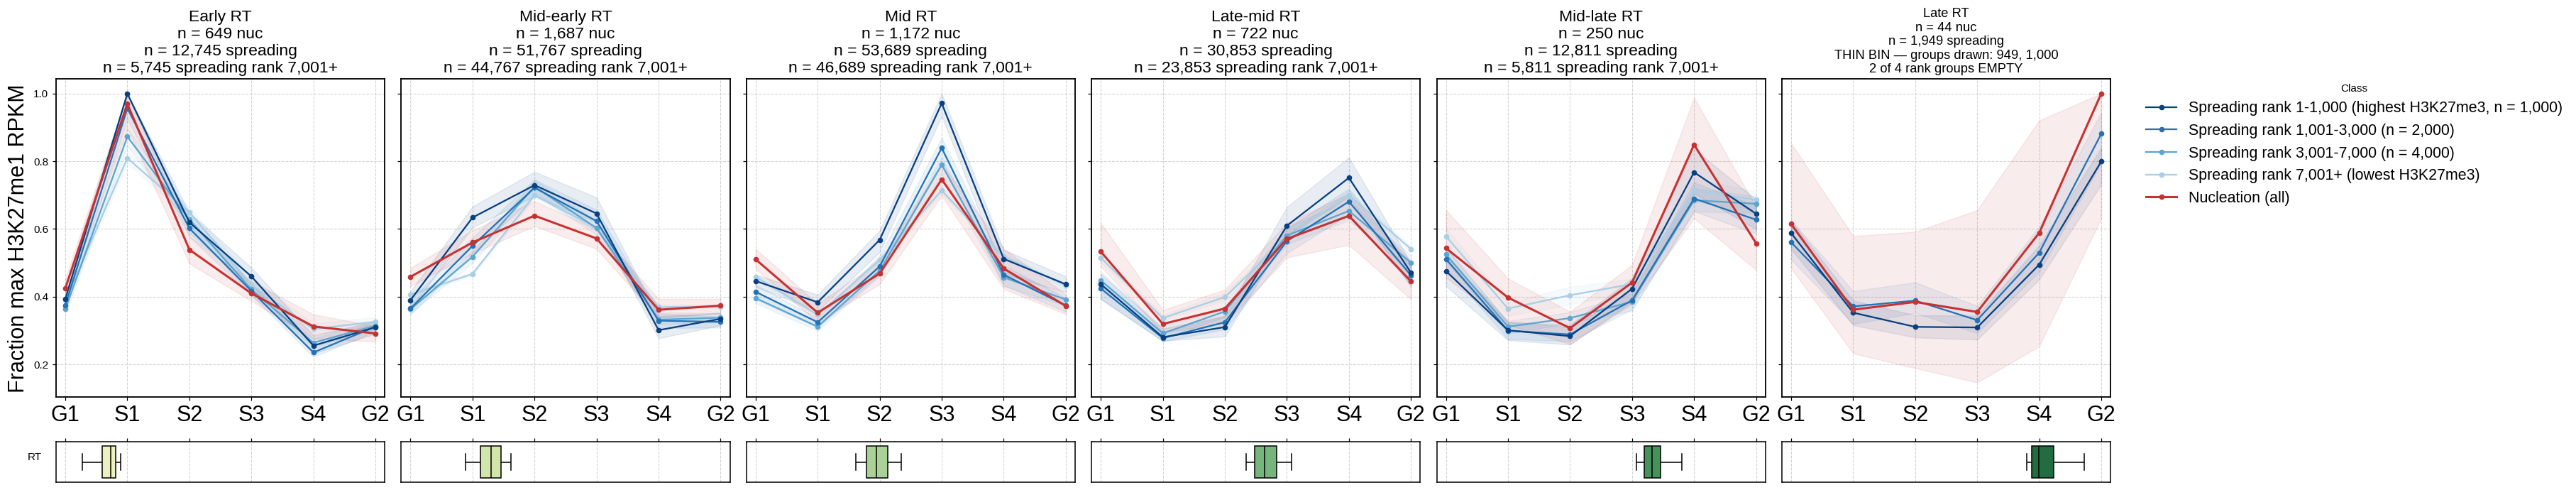

In [7]:
def rank_groups_by_rt(cols, bincol="rt_bin"):
    """The four me3-rank groups + nucleation, per RT bin, on an arbitrary trajectory.

    `bincol` is a parameter only so the guard below can run this same code path against the
    H3K27me3 section's own binning. A group the RT bin is too small to fill comes back as None.
    """
    out = {}
    for b in range(6):
        mb  = D[D[bincol] == b]
        nuc = mb[mb.cls == "nuc"]
        spr = mb[mb.cls == "spread"]
        rk  = spr[LEVELCOL].rank(method="first", ascending=False)     # rank 1 = highest H3K27me3
        gi  = [(rk >= lo) & (rk <= (len(spr) if hi is None else hi)) for lo, hi in GRANGE]
        assert sum(int(m.sum()) for m in gi) == len(spr), f"RT bin {b}: rank groups lost bins"
        out[b] = dict(N=len(nuc), nuc=med_ci(nuc, cols), n_spr=len(spr),
                      g=[med_ci(spr[m], cols) if int(m.sum()) else None for m in gi],
                      g_level=[float(np.median(spr.loc[m, LEVELCOL])) if int(m.sum()) else np.nan
                               for m in gi])
    return out


# guard: fed the me3 columns, this must reproduce `GRES` exactly, down to which groups came
# back empty in the thin RT bin
_chk = rank_groups_by_rt(LMC)
for _b in range(6):
    assert (_chk[_b]["N"], _chk[_b]["n_spr"]) == (GRES[_b]["N"], GRES[_b]["n_spr"])
    assert np.array_equal(_chk[_b]["g_level"], GRES[_b]["g_level"], equal_nan=True)
    for _k in ("med", "lo", "hi"):
        assert np.array_equal(_chk[_b]["nuc"][_k], GRES[_b]["nuc"][_k], equal_nan=True)
        for _i in range(GN):
            assert (_chk[_b]["g"][_i] is None) == (GRES[_b]["g"][_i] is None), (_b, _i)
            if _chk[_b]["g"][_i] is not None:
                assert np.array_equal(_chk[_b]["g"][_i][_k], GRES[_b]["g"][_i][_k], equal_nan=True)

RTHIN = {b: dict(n_spr=_chk[b]["n_spr"],
                 empty=[i for i in range(GN) if _chk[b]["g"][i] is None])
         for b in range(6) if _chk[b]["n_spr"] <= GCUTS[-1]}
if RTHIN:
    print(f"WARNING: the {GCUTS[-1]:,}-deep rank ladder does not fit in {len(RTHIN)} of 6 RT bins "
          f"here either (same bins as section 3). Groups that could not be filled are SKIPPED:")
    for _b, _t in RTHIN.items():
        print(f"  {RL[_b]}: {_t['n_spr']:,} spreading sites; "
              f"{len(_t['empty'])} of {GN} rank groups EMPTY, not drawn — "
              + "; ".join(GLAB[_i] for _i in _t["empty"]))
        print(f"    the top-1,000 group is {100 * GCUTS[0] / _t['n_spr']:.0f}% of this RT bin's "
              f"ENTIRE spreading population, so this panel is NOT equivalent to the others.")
else:
    print(f"the {GCUTS[-1]:,}-deep rank ladder fits in all 6 RT bins")


def draw_rank_groups(res, mark, stem, ylim):
    """The rank-group figure above, redrawn for one mark. Groups, colours, cuts, layout unchanged."""
    fig = plt.figure(figsize=(28, 6))
    gs  = fig.add_gridspec(2, 6, height_ratios=[5.5, 0.7], hspace=0.25)
    for b in range(6):
        e  = res[b]
        ax = fig.add_subplot(gs[0, b])
        _drawn = [i for i in range(GN) if e["g"][i] is not None]   # empty groups absent, not NaN
        for i in _drawn:
            ax.fill_between(XT, e["g"][i]["lo"], e["g"][i]["hi"], color=GCLR[i], alpha=0.09,
                            zorder=2)
        ax.fill_between(XT, e["nuc"]["lo"], e["nuc"]["hi"], color=CLR["nuc"], alpha=0.09, zorder=2)
        for i in _drawn:
            ax.plot(XT, e["g"][i]["med"], label=GLAB[i], color=GCLR[i], linestyle="-", marker="o",
                    markersize=4, linewidth=1.5, zorder=4)
        ax.plot(XT, e["nuc"]["med"], label="Nucleation (all)", color=CLR["nuc"], linestyle="-",
                marker="o", markersize=4, linewidth=2.0, zorder=5)
        ax.set_xlim(XLOW, XHI); ax.set_ylim(*ylim)
        ax.set_xticks(XT); ax.set_xticklabels(PH, rotation=0, ha="center", fontsize=20)
        _t = f"{RL[b]}\nn = {e['N']:,} nuc\nn = {e['n_spr']:,} spreading"
        if b in RTHIN:
            _t += (f"\nTHIN BIN — groups drawn: "
                   + ", ".join(format(e["g"][i]["n"], ",") for i in _drawn)
                   + f"\n{GN - len(_drawn)} of {GN} rank groups EMPTY")
        else:
            _t += f"\nn = {e['g'][0]['n']:,} spreading rank 7,001+"
        ax.set_title(_t, fontsize=15 if b not in RTHIN else 12)
        ax.grid(axis="both", color="lightgray", linestyle="--", linewidth=0.7)
        if b == 0:
            ax.set_ylabel(f"Fraction max {mark} RPKM", fontsize=20)
        else:
            ax.set_yticklabels([])
        for spine in ax.spines.values():
            spine.set_edgecolor("black"); spine.set_linewidth(1.2)
        _rt_strip(fig, gs, b)

    _seen = {}
    for _ax in fig.axes:
        for _h, _l in zip(*_ax.get_legend_handles_labels()):
            _seen.setdefault(_l, _h)
    _order = GLAB[::-1] + ["Nucleation (all)"]
    assert set(_seen) == set(_order), \
        f"legend lost a group across all panels: missing {sorted(set(_order) - set(_seen))}"
    pairs  = sorted(_seen.items(), key=lambda x: _order.index(x[0]))
    ls, hs = zip(*[(l, h) for l, h in pairs])
    fig.legend(hs, ls, title="Class", bbox_to_anchor=(0.98, 0.95), loc="upper left",
               frameon=False, fontsize=14)
    fig.subplots_adjust(left=0.03, right=0.97, top=0.93, bottom=0.07, wspace=0.05, hspace=0.1)
    for ext in ["pdf", "png"]:
        fig.savefig(FIG / f"{stem}.{ext}", bbox_inches="tight",
                    dpi=None if ext == "pdf" else 200)
    plt.show()


_rows = []
for _lab in ["H3K27me2", "H3K27me1"]:
    _cols, _pre = MARK_TRAJ[_lab]
    _res = rank_groups_by_rt(_cols)
    # only bands that exist contribute: an absent or all-NaN band would poison the y-range of the
    # whole figure through nanmin
    def _bands(b, r=_res):
        return [e for e in [r[b]["nuc"]] + [g for g in r[b]["g"] if g is not None]
                if np.isfinite(e["lo"]).any() and np.isfinite(e["hi"]).any()]

    _lo  = min(float(np.nanmin(e["lo"])) for b in range(6) for e in _bands(b))
    _hi  = max(float(np.nanmax(e["hi"])) for b in range(6) for e in _bands(b))
    _yl  = (_lo - 0.05 * (_hi - _lo), _hi + 0.05 * (_hi - _lo))
    draw_rank_groups(_res, _lab, f"fig_{_pre}_spreading_by_me3rank_CI95band", _yl)
    assert _yl[0] <= _lo and _yl[1] >= _hi, "rank-group figure clips a CI band"

    for b in range(6):
        e = _res[b]
        for j, ph in enumerate(PH):
            row = dict(mark_plotted=_lab, mark_grouped_on="H3K27me3", rt_bin=RL[b], fraction=ph,
                       time=STAGE_TIME[ph], band="CI95_of_median_binomial_order_statistic",
                       value_scale="max_normalized_fraction_of_max_RPKM",
                       group_variable=LEVELCOL, group_scope="descending rank within RT bin",
                       group_rank_cuts="1000/3000/7000", y_range=f"{_yl[0]:.4f}-{_yl[1]:.4f}",
                       rt_binning=RT_BIN_SCHEME,
                       rank_ladder_fits=bool(b not in RTHIN),
                       n_rank_groups_empty=(GN - sum(g is not None for g in e["g"])),
                       top1k_frac_of_spreading_pool=GCUTS[0] / e["n_spr"],
                       n_spreading_pool=e["n_spr"], n_nucleation=e["N"],
                       nucleation_all=e["nuc"]["med"][j],
                       nucleation_all_ci95lo=e["nuc"]["lo"][j],
                       nucleation_all_ci95hi=e["nuc"]["hi"][j])
            for i in range(GN):
                _lo_r, _hi_r = GRANGE[i]
                _hi_r = e["n_spr"] if _hi_r is None else _hi_r
                _g = e["g"][i]
                row[f"rank_range_G{i+1}"]         = f"{_lo_r}-{_hi_r}"
                row[f"n_spreading_G{i+1}"]        = 0 if _g is None else _g["n"]
                row[f"median_me3_maxrpkm_G{i+1}"] = e["g_level"][i]
                row[f"spreading_G{i+1}"]          = np.nan if _g is None else _g["med"][j]
                row[f"spreading_G{i+1}_ci95lo"]   = np.nan if _g is None else _g["lo"][j]
                row[f"spreading_G{i+1}_ci95hi"]   = np.nan if _g is None else _g["hi"][j]
            _rows.append(row)
pd.DataFrame(_rows).to_csv(FIG / "me2_me1_spreading_by_me3rank_CI95band.tsv", sep="\t", index=False)

# Nucleation over Spreading line plots

In [8]:
# Pairing unit: one (super-domain x RT bin) cell, i.e. the bins of a single super-domain falling in
# a single RT bin. A cell is used only if it holds at least one nucleation bin and at least one
# spreading bin of the relevant kind, so every contrast is formed inside one super-domain and inside
# one RT bin, then aggregated across cells.
MC_COLS = [f"me3_{p}" for p in PH]      # raw RPKM   — reference contrast only
LM_COLS = LMC                           # max-scaled — the DRAWN contrast
UNIT    = "domain_id"                   # the TRUE <=10 kb-merged super-domain

assert (SWARM_CLR["nuc"], SWARM_CLR["cpgonly"], SWARM_CLR["spread"]) \
       == (CLR["nuc"], CLR["cpg"], CLR["spr"]), "figure A / beeswarm colours have drifted apart"


def log2_ratio(a, b_):
    """log2(a/b), NaN unless both sides are finite and strictly positive."""
    ok = np.isfinite(a) & np.isfinite(b_) & (a > 0) & (b_ > 0)
    return np.where(ok, np.log2(np.where(ok, a, 1.0) / np.where(ok, b_, 1.0)), np.nan)


def build_cells(unit, lm_cols=None, mc_cols=None):
    """Every (unit x RT bin) cell with >=1 nucleation and >=1 spreading bin, and its contrasts.

    `lm_cols` / `mc_cols` default to the H3K27me3 columns. Passing the me2 / me1 columns reproduces
    this contrast for another mark with everything else held fixed: same classes, same `topN` and
    `top1k` selections (both defined on me3, neither redefined per mark), same pairing unit.

    Three spreading denominators are built. `topN` (top-N by `mc`, N = this RT bin's nucleation
    count) is what the grid below draws; `top1k` (this RT bin's top 1,000 by `maxrpkm`) is what the
    statistics section tests; `all` is the full spreading population, shared by both. They rank on
    different columns and are not interchangeable.
    """
    lm_cols = LM_COLS if lm_cols is None else lm_cols
    mc_cols = MC_COLS if mc_cols is None else mc_cols
    out = []
    for (u, b), g in D[D.cls.isin(["nuc", "spread"])].groupby([unit, "rt_bin"], sort=True):
        nu = g[g.cls == "nuc"]; sp = g[g.cls == "spread"]
        if len(nu) == 0 or len(sp) == 0:
            continue                                          # not a paired cell
        tp = sp[sp.topN]                                      # the top-N arm, inside this cell
        tk = sp[sp.top1k]                                     # the top-1,000 arm, inside this cell
        Wn, Ws = nu[lm_cols].to_numpy(float), sp[lm_cols].to_numpy(float)
        Vn, Vs = nu[mc_cols].to_numpy(float), sp[mc_cols].to_numpy(float)   # raw-RPKM reference
        num, dall   = np.nanmedian(Wn, axis=0), np.nanmedian(Ws, axis=0)
        rnum, rdall = np.median(Vn, axis=0),    np.median(Vs, axis=0)
        has_top = len(tp) > 0
        dtop  = np.nanmedian(tp[lm_cols].to_numpy(float), axis=0) if has_top else np.full(6, np.nan)
        rdtop = np.median(tp[mc_cols].to_numpy(float), axis=0)    if has_top else np.full(6, np.nan)
        has_1k = len(tk) > 0
        d1k  = np.nanmedian(tk[lm_cols].to_numpy(float), axis=0) if has_1k else np.full(6, np.nan)
        rd1k = np.median(tk[mc_cols].to_numpy(float), axis=0)    if has_1k else np.full(6, np.nan)
        row = dict(unit=u, rt_bin=int(b), n_nuc_cell=len(nu), n_spr_cell=len(sp), n_top_cell=len(tp),
                   n_top1k_cell=len(tk),
                   mc_nuc=float(np.median(nu[COVCOL])), mc_spr_all=float(np.median(sp[COVCOL])),
                   mc_spr_topN=float(np.median(tp[COVCOL])) if has_top else np.nan,
                   mc_spr_top1k=float(np.median(tk[COVCOL])) if has_1k else np.nan)
        for j, ph in enumerate(PH):
            row[f"l2_topN_{ph}"]    = float(log2_ratio(num[j],  dtop[j]))    # DRAWN, max-norm
            row[f"l2_top1k_{ph}"]   = float(log2_ratio(num[j],  d1k[j]))     # TESTED, max-norm
            row[f"l2_all_{ph}"]     = float(log2_ratio(num[j],  dall[j]))    # DRAWN + TESTED
            row[f"l2raw_topN_{ph}"] = float(log2_ratio(rnum[j], rdtop[j]))   # reference, raw
            row[f"l2raw_top1k_{ph}"] = float(log2_ratio(rnum[j], rd1k[j]))   # reference, raw
            row[f"l2raw_all_{ph}"]  = float(log2_ratio(rnum[j], rdall[j]))   # reference, raw
        out.append(row)
    return pd.DataFrame(out)


def aggregate(C):
    """Median + 95% CI across cells, per RT bin, for each denominator."""
    R = {}
    for b in range(6):
        s = C[C.rt_bin == b]
        e = dict(n_cells_all=len(s), n_cells_topN=int((s.n_top_cell > 0).sum()),
                 n_cells_top1k=int((s.n_top1k_cell > 0).sum()),
                 n_nuc_all=int(s.n_nuc_cell.sum()),
                 n_nuc_topN=int(s.loc[s.n_top_cell > 0, "n_nuc_cell"].sum()),
                 n_nuc_top1k=int(s.loc[s.n_top1k_cell > 0, "n_nuc_cell"].sum()))
        for key, pre in [("topN", "l2_topN"), ("top1k", "l2_top1k"), ("all", "l2_all"),
                         ("topN_raw", "l2raw_topN"), ("top1k_raw", "l2raw_top1k"),
                         ("all_raw", "l2raw_all")]:
            med, lo, hi = median_ci(s[[f"{pre}_{p}" for p in PH]].to_numpy(float))
            e[key] = dict(med=med, lo=lo, hi=hi)
        R[b] = e
    return R


CELLS = build_cells(UNIT)
RATIO = aggregate(CELLS)
CELLS.to_csv(FIG / "me3_nuc_over_spreading_superdomain_cells.tsv", sep="\t", index=False)

CELLS_SUP = build_cells("super"); RATIO_SUP = aggregate(CELLS_SUP)
POOLED = {}
for b in range(6):
    mb = D[D.rt_bin == b]
    n = np.nanmedian(mb.loc[mb.cls == "nuc", LM_COLS].to_numpy(float), axis=0)
    POOLED[b] = dict(
        all=log2_ratio(n, np.nanmedian(mb.loc[mb.cls == "spread", LM_COLS].to_numpy(float), axis=0)),
        topN=log2_ratio(n, np.nanmedian(mb.loc[mb.topN, LM_COLS].to_numpy(float), axis=0)),
        top1k=log2_ratio(n, np.nanmedian(mb.loc[mb.top1k, LM_COLS].to_numpy(float), axis=0)))

rows = []
for b in range(6):
    e = RATIO[b]
    for j, ph in enumerate(PH):
        r = dict(rt_bin=RL[b], fraction=ph, time=STAGE_TIME[ph],
                 band="CI95_of_median_binomial_order_statistic",
                 value_scale="max_normalized_fraction_of_max_RPKM", pairing_unit=UNIT,
                 n_superdomain_cells_all=e["n_cells_all"], n_superdomain_cells_topN=e["n_cells_topN"],
                 n_superdomain_cells_top1k=e["n_cells_top1k"],
                 n_nucleation_bins_all=e["n_nuc_all"], n_nucleation_bins_topN=e["n_nuc_topN"],
                 n_nucleation_bins_top1k=e["n_nuc_top1k"],
                 log2_nuc_over_all_spreading_POOLED=float(POOLED[b]["all"][j]),
                 log2_nuc_over_topN_spreading_POOLED=float(POOLED[b]["topN"][j]),
                 log2_nuc_over_top1k_spreading_POOLED=float(POOLED[b]["top1k"][j]),
                 log2_nuc_over_all_spreading_LEGACYSUPER=RATIO_SUP[b]["all"]["med"][j],
                 log2_nuc_over_topN_spreading_LEGACYSUPER=RATIO_SUP[b]["topN"]["med"][j],
                 log2_nuc_over_top1k_spreading_LEGACYSUPER=RATIO_SUP[b]["top1k"]["med"][j])
        for key, pre in [("topN",      "log2_nuc_over_topN_spreading"),
                         ("top1k",     "log2_nuc_over_top1k_spreading"),
                         ("all",       "log2_nuc_over_all_spreading"),
                         ("topN_raw",  "log2_nuc_over_topN_spreading_RAWRPKM"),
                         ("top1k_raw", "log2_nuc_over_top1k_spreading_RAWRPKM"),
                         ("all_raw",   "log2_nuc_over_all_spreading_RAWRPKM")]:
            r[pre] = e[key]["med"][j]
            r[f"{pre}_ci95lo"] = e[key]["lo"][j]
            r[f"{pre}_ci95hi"] = e[key]["hi"][j]
        rows.append(r)
RATIO_T = pd.DataFrame(rows)
RATIO_T.to_csv(FIG / "me3_nuc_over_spreading_superdomain_paired.tsv", sep="\t", index=False)

In [9]:
#paired contrast for H3K27me2 and H3K27me1
RATIO_MARK, CELLS_MARK = {}, {}
for _mk, _pre, _lab in MARK_SPEC:
    lmc, mcc = MARK_COLS[_lab]
    C = build_cells(UNIT, lm_cols=lmc, mc_cols=mcc)
    CELLS_MARK[_lab] = C
    RATIO_MARK[_lab] = aggregate(C)
    C.to_csv(FIG / f"{_pre}_nuc_over_spreading_superdomain_cells.tsv", sep="\t", index=False)

    rows = []
    for b in range(6):
        e = RATIO_MARK[_lab][b]
        for j, ph in enumerate(PH):
            r = dict(mark=_lab, rt_bin=RL[b], fraction=ph, time=STAGE_TIME[ph],
                     band="CI95_of_median_binomial_order_statistic", pairing_unit=UNIT,
                     value_scale="max_normalized_fraction_of_max_RPKM",
                     topN_selection="defined on H3K27me3 counts (mc), identical across marks",
                     top1k_selection="defined on H3K27me3 maxrpkm, top 1,000 within RT bin, "
                                     "identical across marks",
                     n_superdomain_cells_all=e["n_cells_all"],
                     n_superdomain_cells_topN=e["n_cells_topN"],
                     n_superdomain_cells_top1k=e["n_cells_top1k"])
            for key, pre in [("topN",  "log2_nuc_over_topN_spreading"),
                             ("top1k", "log2_nuc_over_top1k_spreading"),
                             ("all",   "log2_nuc_over_all_spreading"),
                             ("topN_raw",  "log2_nuc_over_topN_spreading_RAWRPKM"),
                             ("top1k_raw", "log2_nuc_over_top1k_spreading_RAWRPKM"),
                             ("all_raw",   "log2_nuc_over_all_spreading_RAWRPKM")]:
                r[pre] = e[key]["med"][j]
                r[f"{pre}_ci95lo"] = e[key]["lo"][j]
                r[f"{pre}_ci95hi"] = e[key]["hi"][j]
            rows.append(r)
    pd.DataFrame(rows).to_csv(FIG / f"{_pre}_nuc_over_spreading_superdomain_paired.tsv",
                              sep="\t", index=False)

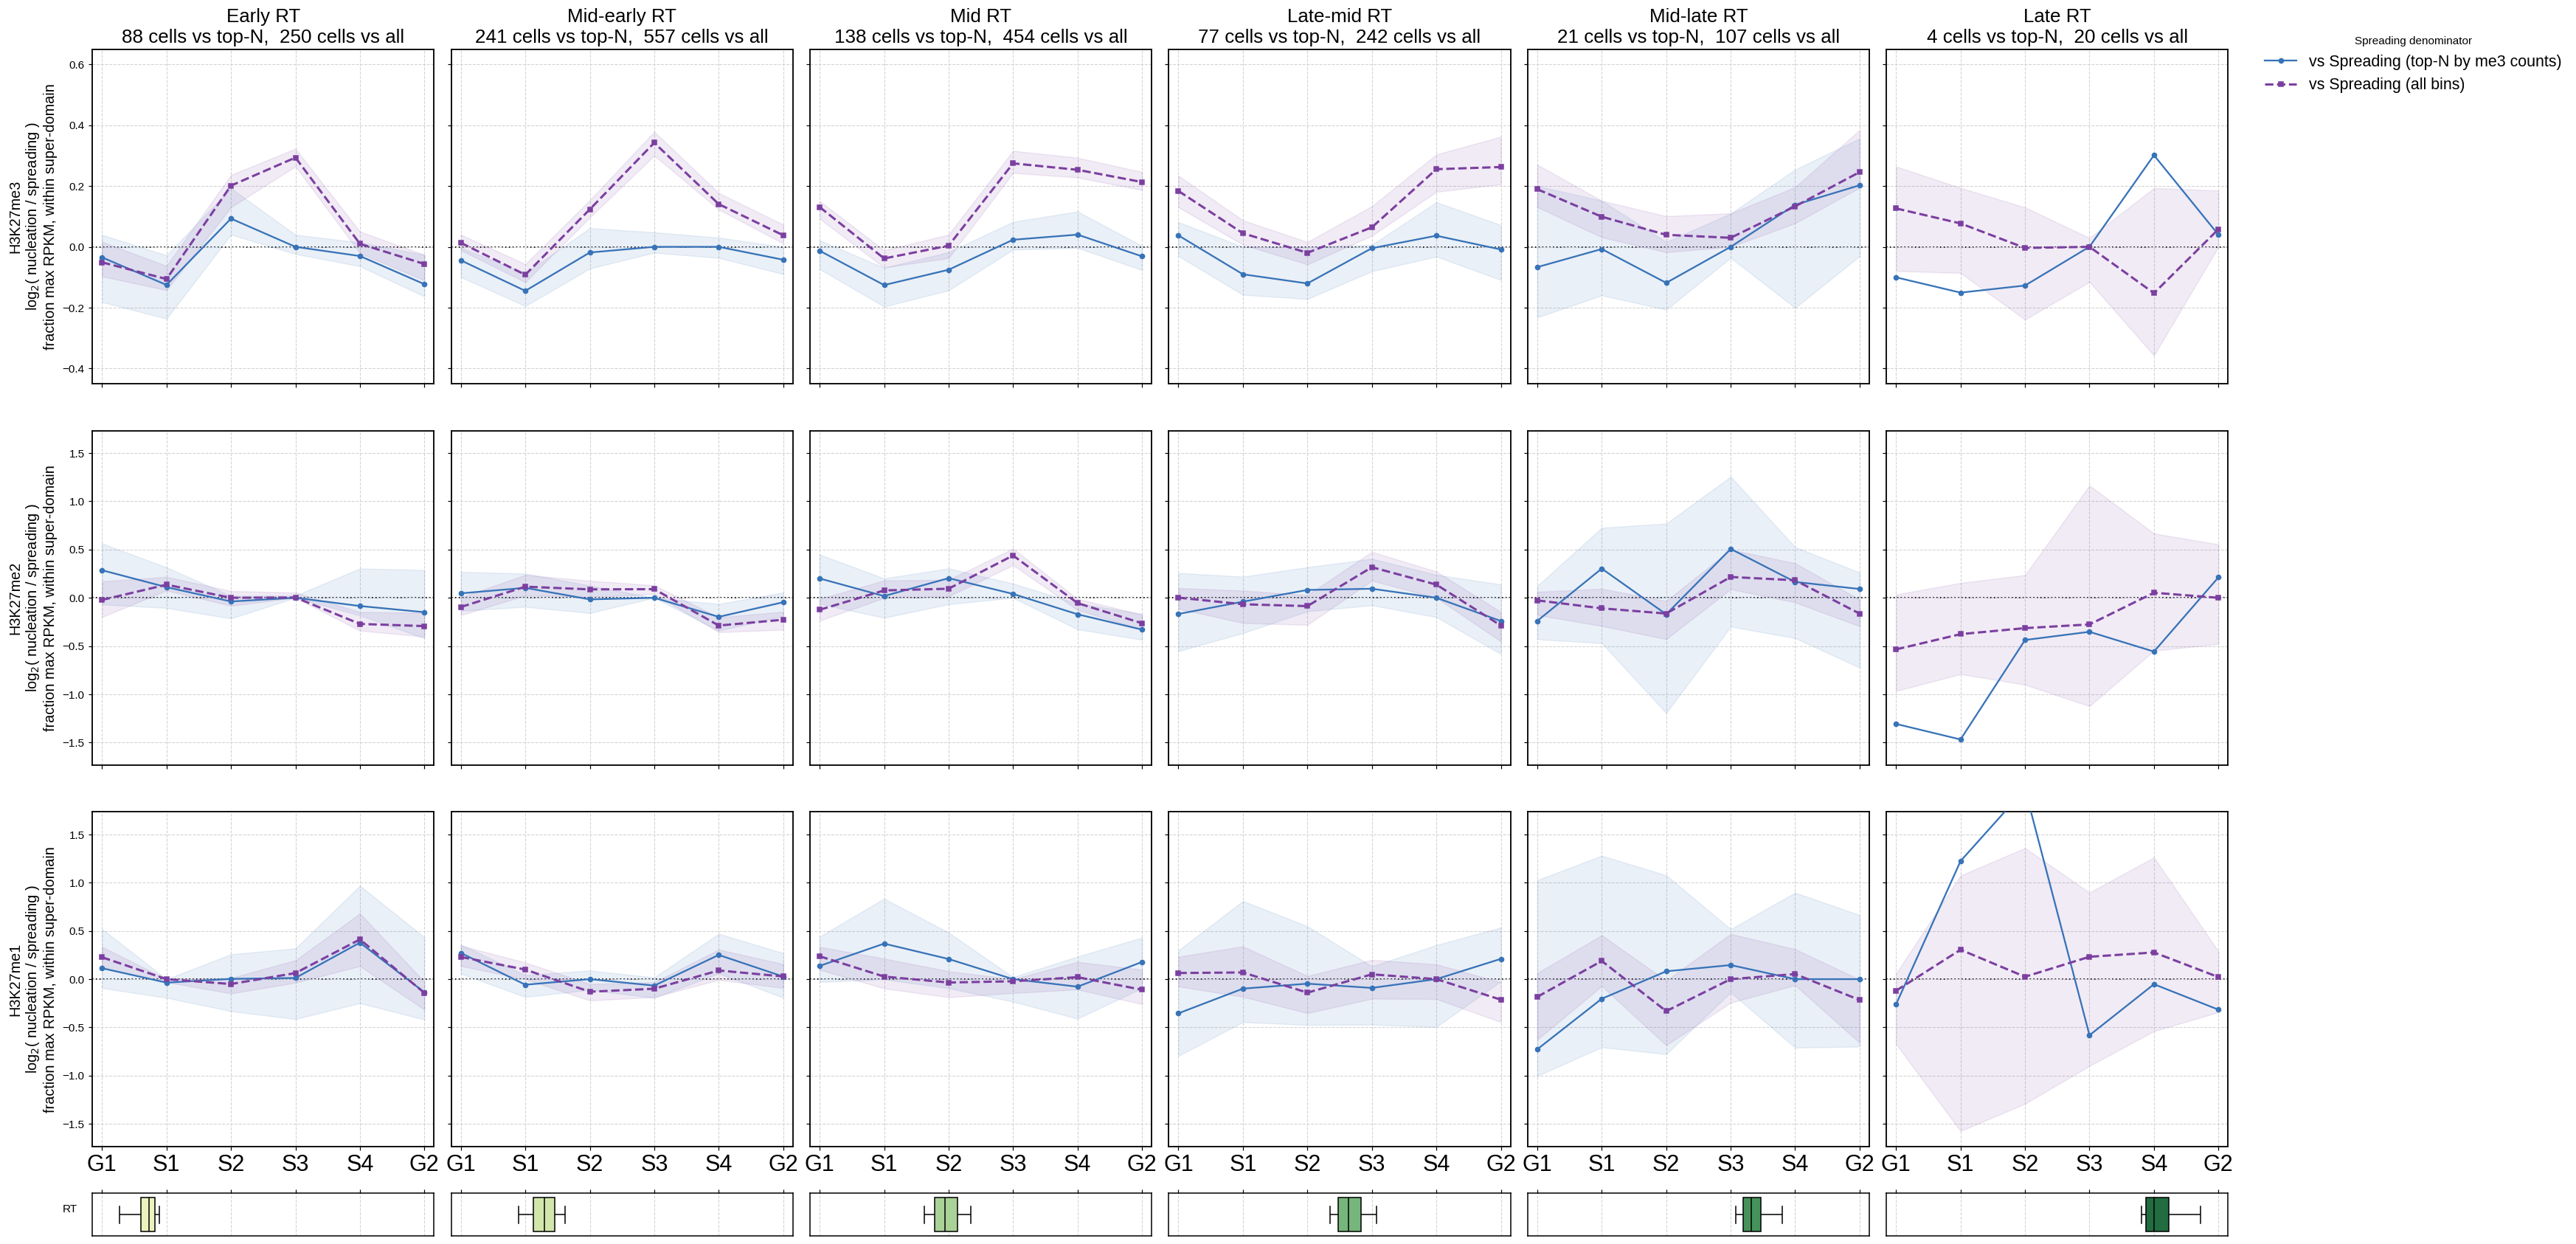

In [10]:
# y = log2(nucleation / spreading) of the max-normalized signal, paired within one super-domain.
# y = 0 means the two classes hold the same fraction of their own maximum at that point in the cycle.
#     vs top-N spreading   #3773b8 blue    solid,  circle   <- coverage-selected subset (`topN`)
#     vs all spreading     #7B3FA0 purple  dashed, square   <- the full-population reference
RAT_ORDER = ["topN", "all"]
RAT_LAB   = {"topN": "vs Spreading (top-N by me3 counts)",
             "all":  "vs Spreading (all bins)"}
RAT_CLR   = {"topN": CLR["spr"], "all": CLR["sprall"]}
RAT_STY   = {"topN": "-",  "all": "--"}
RAT_MRK   = {"topN": "o",  "all": "s"}
RAT_LW    = {"topN": 1.5,  "all": 2.0}

# me3 keeps its own narrower range; me2 + me1 share a symmetric data-derived range. The three rows
# are therefore not on a common y-scale: compare the numbers, not the visual amplitude, across rows.
RYLO, RYHI = -0.45, 0.65
_absmax = max(abs(v) for _, _, _l in MARK_SPEC
              for b in range(6) for k in RAT_ORDER
              for v in (np.nanmin(RATIO_MARK[_l][b][k]["lo"]),
                        np.nanmax(RATIO_MARK[_l][b][k]["hi"])))
MYLO, MYHI = -(_absmax * 1.10), _absmax * 1.10

GRID_ROWS = [("H3K27me3", RATIO,                  (RYLO, RYHI)),
             ("H3K27me2", RATIO_MARK["H3K27me2"], (MYLO, MYHI)),
             ("H3K27me1", RATIO_MARK["H3K27me1"], (MYLO, MYHI))]

fig = plt.figure(figsize=(28, 17))
gs  = fig.add_gridspec(4, 6, height_ratios=[5.5, 5.5, 5.5, 0.7], hspace=0.18)

for r, (mark_label, R, (ylo, yhi)) in enumerate(GRID_ROWS):
    for b in range(6):
        e  = R[b]
        ax = fig.add_subplot(gs[r, b])
        ax.axhline(0.0, color="black", lw=1.2, ls=":", zorder=1)      # no-difference line

        for key in RAT_ORDER:
            ax.fill_between(XT, e[key]["lo"], e[key]["hi"], color=RAT_CLR[key], alpha=0.10, zorder=2)
        for key in RAT_ORDER:
            ax.plot(XT, e[key]["med"], label=RAT_LAB[key], color=RAT_CLR[key],
                    linestyle=RAT_STY[key], marker=RAT_MRK[key], markersize=4,
                    linewidth=RAT_LW[key], zorder=3)

        ax.set_xlim(XLOW, XHI); ax.set_ylim(ylo, yhi)
        ax.set_xticks(XT)
        # cell-cycle fraction labels on the bottom row of line plots only; the columns share x
        ax.set_xticklabels(PH if r == len(GRID_ROWS) - 1 else [],
                           rotation=0, ha="center", fontsize=20)
        if r == 0:
            # cell counts are identical for all three marks (the cells are defined by class
            # membership, not by the plotted values), so the column title carries them once
            ax.set_title(f"{RL[b]}\n{e['n_cells_topN']:,} cells vs top-N,  "
                         f"{e['n_cells_all']:,} cells vs all", fontsize=17)
        ax.grid(axis="both", color="lightgray", linestyle="--", linewidth=0.7)
        if b == 0:
            ax.set_ylabel(f"{mark_label}\nlog$_2$( nucleation / spreading )\n"
                          "fraction max RPKM, within super-domain", fontsize=13)
        else:
            ax.set_yticklabels([])
        for spine in ax.spines.values():
            spine.set_edgecolor("black"); spine.set_linewidth(1.2)

for b in range(6):
    _rt_strip(fig, gs, b, row=3)

handles, labels = ax.get_legend_handles_labels()
pairs = sorted([(h, l) for h, l in zip(handles, labels) if l in RAT_LAB.values()],
               key=lambda x: [RAT_LAB[k] for k in RAT_ORDER].index(x[1]))
hs, ls = zip(*pairs)
fig.legend(hs, ls, title="Spreading denominator", bbox_to_anchor=(0.98, 0.95),
           loc="upper left", frameon=False, fontsize=14)

fig.subplots_adjust(left=0.03, right=0.97, top=0.93, bottom=0.07, wspace=0.05, hspace=0.1)

GSTEM = "fig_nuc_over_spreading_me3_me2_me1_grid"
for ext in ["pdf", "png"]:
    fig.savefig(FIG / f"{GSTEM}.{ext}", bbox_inches="tight",
                dpi=None if ext == "pdf" else 200)

clip = [(mark_label, RL[b], key) for mark_label, R, (ylo, yhi) in GRID_ROWS
        for b in range(6) for key in RAT_ORDER
        if np.nanmin(R[b][key]["lo"]) < ylo or np.nanmax(R[b][key]["hi"]) > yhi]
assert not clip, f"grid clips: {clip}"
plt.show()

# Statistics of Nucleation over Spreading after controlling for me3 levels.

In [11]:
# One-sided Wilcoxon signed-rank + BH-FDR, per mark x spreading arm.
# The unit is one (domain_id x RT bin) super-domain cell; the value is already a within-cell log
# ratio, so a one-sample signed-rank test of those values is the paired test. The family is at most
# 6 RT bins x 6 cell-cycle fractions = 36 tests per (mark x arm); the two denominators are separate
# arms and are never pooled. At most, not exactly: an RT bin can be thin enough that a cell falls
# below MIN_CELLS and is not tested, and BH then runs over a shorter family. Any such cell is
# printed by name below and the true family size is written into every row of the saved table.
#
# The arms are the rank-group section's categories, not the line plot's. The first arm is that
# section's `Spreading rank 1-1,000` group: 1,000 bins per RT bin, ranked on `maxrpkm` (`D.top1k`).
# The second is the whole spreading population. The grid above draws the top-N arm (`D.topN`, ranked
# on `mc`), so the figure above and the table below use different first denominators by
# construction. `arm_denominator` in the saved table names which.

MIN_CELLS = 10           # below this a signed-rank p is not resolvable; the test is not run
FIGB_MARKS = [("H3K27me3", CELLS), ("H3K27me2", CELLS_MARK["H3K27me2"]),
              ("H3K27me1", CELLS_MARK["H3K27me1"])]
FIGB_ARMS  = [("top1k", "l2_top1k", "top 1,000 spreading per RT bin (maxrpkm rank 1-1,000)"),
              ("all", "l2_all", "all spreading")]


def bh_fdr(p):
    """Benjamini-Hochberg adjusted p-values (step-up), order preserved. NaN-free input."""
    p = np.asarray(p, float); m = p.size
    o = np.argsort(p); q = np.empty(m); run = 1.0
    for i in range(m - 1, -1, -1):
        run = min(run, p[o[i]] * m / (i + 1)); q[o[i]] = run
    return q


def by_fdr(p):
    """Benjamini-Yekutieli: BH inflated by the harmonic sum c(m) - valid under ANY dependence."""
    p = np.asarray(p, float)
    return np.minimum(1.0, bh_fdr(p) * float(np.sum(1.0 / np.arange(1, p.size + 1))))


rows = []
for mark, C in FIGB_MARKS:
    for arm, key, arm_lab in FIGB_ARMS:
        blk = []
        for b in range(6):
            s = C[C.rt_bin == b]
            for ph in PH:
                v = s[f"{key}_{ph}"].to_numpy(float)
                v = v[np.isfinite(v)]                       # cells with no top-N bin drop out here
                n, nzero, npos = v.size, int((v == 0).sum()), int((v > 0).sum())
                r = dict(mark=mark, arm=arm, arm_denominator=arm_lab, rt_bin=RL[b], rt_bin_index=b,
                         fraction=ph, time=STAGE_TIME[ph], n_superdomain_cells=n,
                         n_cells_exactly_zero=nzero, n_cells_positive=npos,
                         frac_cells_positive=npos / n if n else np.nan,
                         median_log2_nuc_over_spreading=float(np.median(v)) if n else np.nan)
                r["fold_linear"] = float(2 ** r["median_log2_nuc_over_spreading"]) if n else np.nan
                if n >= MIN_CELLS:
                    # primary: zsplit keeps the exact-zero cells (they are evidence for H0) and
                    # splits their ranks, the conservative choice when zeros are structural
                    W, p1 = wilcoxon(v, alternative="greater", zero_method="zsplit")
                    r["W_signed_rank"] = float(W)
                    r["p_one_sided"]   = float(p1)
                    # matched-pairs rank-biserial: 2*T+/(n(n+1)/2) - 1, in [-1, 1]
                    r["rank_biserial"] = float(2 * W / (n * (n + 1) / 2) - 1)
                    # sensitivity 1: Wilcoxon's original rule (DISCARD zeros)
                    r["p_one_sided_discard_zeros"] = float(
                        wilcoxon(v, alternative="greater", zero_method="wilcox")[1]) \
                        if (n - nzero) >= MIN_CELLS else np.nan
                    # sensitivity 2: distribution-free sign test on the non-zero cells
                    r["p_one_sided_sign_test"] = float(
                        binomtest(npos, n - nzero, 0.5, alternative="greater").pvalue) \
                        if (n - nzero) > 0 else np.nan
                else:
                    for k in ["W_signed_rank", "p_one_sided", "rank_biserial",
                              "p_one_sided_discard_zeros", "p_one_sided_sign_test"]:
                        r[k] = np.nan
                blk.append(r)

        assert len(blk) == 36, f"{mark}/{arm}: {len(blk)} tests, expected 6 fractions x 6 RT bins"
        run = [r for r in blk if np.isfinite(r["p_one_sided"])]

        # a family that silently shortens from 36 is a different multiple-testing correction
        # reported under the same name, so every cell that did not run is named here and the true
        # family size is carried into every row of the saved table
        _miss = [r for r in blk if not np.isfinite(r["p_one_sided"])]
        if _miss:
            print(f"  {mark} / {arm}: {len(run)}/36 tests ran — {len(_miss)} cell(s) below "
                  f"MIN_CELLS = {MIN_CELLS} and NOT tested:")
            for r in _miss:
                print(f"    {r['rt_bin']:<13} {r['fraction']:<3} "
                      f"n_superdomain_cells = {r['n_superdomain_cells']}")
            print(f"    -> BH-FDR for this family is over {len(run)} tests, not 36; "
                  f"`fdr_family` and `n_tests_in_family` in the saved table say so.")
        assert len(run) > 0, f"{mark}/{arm}: no test in the family ran at all"

        # BH-FDR over this family only; arms are separate families, never pooled. Untested cells are
        # excluded from the correction rather than passed in as NaN: including them would inflate m
        # and make every q in the family conservative by an undeclared factor.
        for src, dst, fn in [("p_one_sided", "q_BH", bh_fdr),
                             ("p_one_sided", "q_BY_any_dependence", by_fdr),
                             ("p_one_sided_discard_zeros", "q_BH_discard_zeros", bh_fdr),
                             ("p_one_sided_sign_test", "q_BH_sign_test", bh_fdr)]:
            _ok = [r for r in blk if np.isfinite(r[src])]
            for r in blk:
                r[dst] = np.nan
            if _ok:
                for r, q in zip(_ok, fn([r[src] for r in _ok])):
                    r[dst] = float(q)
        for r in blk:
            r["test_ran"]          = bool(np.isfinite(r["p_one_sided"]))
            r["n_tests_in_family"] = len(run)
            r["min_cells_for_test"] = MIN_CELLS
            e = effect_gate(2 ** r["median_log2_nuc_over_spreading"])
            _fam = (f"{len(run)} tests" if len(run) == 36 else
                    f"{len(run)} tests of 36 cells; {36 - len(run)} below MIN_CELLS = {MIN_CELLS}")
            r["fdr_family"]     = f"{mark} / {arm} spreading ({_fam})"
            r["significant_q05"] = bool(np.isfinite(r["q_BH"]) and r["q_BH"] < 0.05)
            r["effect_gate"]     = float(FOLD_GATE)
            r["effect_gate_scale"] = GATE_SCALE
            # one-sided, so the gate is one-sided too: the effect must be >= +gate, not just |>=|
            r["passes_effect_gate"] = bool(r["median_log2_nuc_over_spreading"] >= FOLD_GATE)
            r["significant_q05_and_effect_gate"] = bool(r["significant_q05"]
                                                        and r["passes_effect_gate"])
        rows += blk

FIGB_T = pd.DataFrame(rows)
FIGB_T.insert(0, "test", "one-sided Wilcoxon signed-rank, H1: median log2(nuc/spread) > 0")
FIGB_T["pairing_unit"] = f"{UNIT} x RT bin (super-domain cell)"
FIGB_T["value_scale"]  = "max_normalized_fraction_of_max_RPKM (figure A/B units)"
FIGB_OUT = FIG / "figB_nuc_over_spreading_wilcoxon_BH.tsv"
# written by the equivalence-extension cell below, which left-merges its columns onto
# FIGB_T and saves the superset to this same path

# consistency gate: the table's medians are the aggregated medians, arm for arm
# This ties the table to `aggregate`, not to the grid: the grid draws `topN` + `all` and this table
# tests `top1k` + `all`, so only the `all` arm is common to both.
_dev = []
for mark, R in [("H3K27me3", RATIO), ("H3K27me2", RATIO_MARK["H3K27me2"]),
                ("H3K27me1", RATIO_MARK["H3K27me1"])]:
    for arm, key in [("top1k", "top1k"), ("all", "all")]:
        for b in range(6):
            for j, ph in enumerate(PH):
                t = FIGB_T[(FIGB_T["mark"] == mark) & (FIGB_T.arm == arm)
                           & (FIGB_T.rt_bin_index == b) & (FIGB_T.fraction == ph)]
                _a, _b2 = float(t.median_log2_nuc_over_spreading.iloc[0]), R[b][key]["med"][j]
                # an empty cell is NaN on both sides and that agreement still has to be checked:
                # NaN on one side only is real drift and must not slip through as `nan < 1e-9`
                assert np.isfinite(_a) == np.isfinite(_b2), \
                    f"{mark}/{arm}/{RL[b]}/{ph}: table and aggregate disagree on whether the cell exists"
                _dev.append(0.0 if not np.isfinite(_a) else abs(_a - _b2))
assert max(_dev) < 1e-9, f"table medians drifted from the plotted medians: {max(_dev):.3g}"

  H3K27me1 / top1k: 35/36 tests ran — 1 cell(s) below MIN_CELLS = 10 and NOT tested:
    Late RT       S2  n_superdomain_cells = 9
    -> BH-FDR for this family is over 35 tests, not 36; `fdr_family` and `n_tests_in_family` in the saved table say so.


In [12]:
# Equivalence extension: DIFFERENT / EQUIVALENT / INCONCLUSIVE. Failing to reject H0 means
# "not shown", never "shown to be absent", so each test also gets a two-sided p and q, a
# Hodges-Lehmann estimate with its distribution-free CI, and a TOST at the +-0.2 log2 gate.
def hl_ci(x, alpha=0.05):
    """Hodges-Lehmann pseudo-median and its Wilcoxon-inverted (1-alpha) CI."""
    x = np.asarray(x, float); x = x[np.isfinite(x)]; n = x.size
    if n < 6:
        return np.nan, np.nan, np.nan
    w = np.sort(np.add.outer(x, x)[np.triu_indices(n)] / 2.0)      # Walsh averages
    mu, sd = n * (n + 1) / 4.0, np.sqrt(n * (n + 1) * (2 * n + 1) / 24.0)
    k = max(int(np.floor(mu - norm.ppf(1 - alpha / 2) * sd)), 0)
    return (float(np.median(w)),
            float(w[k]) if k < w.size else np.nan,
            float(w[w.size - 1 - k]) if k < w.size else np.nan)


def tost_p(x, margin):
    """Two one-sided signed-rank tests. Small p => equivalent within +-margin."""
    x = np.asarray(x, float); x = x[np.isfinite(x)]
    if x.size < 6:
        return np.nan
    return float(max(wilcoxon(x + margin, alternative="greater", zero_method="zsplit").pvalue,
                     wilcoxon(x - margin, alternative="less", zero_method="zsplit").pvalue))


rows = []
for mark, Cm in FIGB_MARKS:
    for arm, key, arm_lab in FIGB_ARMS:
        for b in range(6):
            s = Cm[Cm.rt_bin == b]
            for ph in PH:
                v = s[f"{key}_{ph}"].to_numpy(float)
                v = v[np.isfinite(v)]
                est, lo, hi = hl_ci(v, alpha=0.05)          # goes with DIFFERENT
                _, lo90, hi90 = hl_ci(v, alpha=0.10)        # goes with EQUIVALENT
                rows.append(dict(
                    mark=mark, arm=arm, rt_bin=RL[b], fraction=ph, n=v.size,
                    p_two_sided=(float(wilcoxon(v, zero_method="zsplit").pvalue)
                                 if v.size >= MIN_CELLS else np.nan),
                    hl_estimate=est, ci95_lo=lo, ci95_hi=hi,
                    ci90_lo=lo90, ci90_hi=hi90,
                    p_tost_gate=tost_p(v, FOLD_GATE)))
EQ = pd.DataFrame(rows)
EQ["q_two_sided"] = np.nan
for (mark, arm), g in EQ.groupby(["mark", "arm"]):
    _ok = g.index[np.isfinite(g.p_two_sided.to_numpy(float))]
    if len(_ok):
        EQ.loc[_ok, "q_two_sided"] = bh_fdr(EQ.loc[_ok, "p_two_sided"].to_numpy(float))
EQ["tested"] = np.isfinite(EQ.p_two_sided.to_numpy(float))
EQ["equivalent"] = EQ.p_tost_gate < 0.05
EQ["different"] = EQ.q_two_sided < 0.05
EQ["verdict"] = np.where(~EQ.tested, "NOT TESTED (n < MIN_CELLS)",
                         np.where(EQ.different, "DIFFERENT",
                                  np.where(EQ.equivalent, "EQUIVALENT", "INCONCLUSIVE")))
_nt = int((~EQ.tested).sum())
print(f"equivalence verdicts over {len(EQ)} cells: "
      + ", ".join(f"{v} {int((EQ.verdict == v).sum())}" for v in sorted(EQ.verdict.unique())))
if _nt:
    print(f"  the {_nt} NOT TESTED cell(s) are below MIN_CELLS = {MIN_CELLS} and are counted as "
          f"NEITHER inconclusive nor equivalent:")
    for _, _r in EQ[~EQ.tested].iterrows():
        print(f"    {_r['mark']:<9} {_r['arm']:<6} {_r['rt_bin']:<13} {_r['fraction']:<3} "
              f"n = {_r['n']}")
FIGB_T = FIGB_T.merge(EQ[["mark", "arm", "rt_bin", "fraction", "p_two_sided",
                          "q_two_sided", "hl_estimate", "ci95_lo", "ci95_hi",
                          "ci90_lo", "ci90_hi",
                          "p_tost_gate", "tested", "equivalent", "different", "verdict"]],
                      on=["mark", "arm", "rt_bin", "fraction"], how="left")
FIGB_T.to_csv(FIGB_OUT, sep="\t", index=False)

FIGB_T

equivalence verdicts over 216 cells: DIFFERENT 70, EQUIVALENT 58, INCONCLUSIVE 87, NOT TESTED (n < MIN_CELLS) 1
  the 1 NOT TESTED cell(s) are below MIN_CELLS = 10 and are counted as NEITHER inconclusive nor equivalent:
    H3K27me1  top1k  Late RT       S2  n = 9


,test,mark,arm,arm_denominator,rt_bin,rt_bin_index,fraction,time,n_superdomain_cells,n_cells_exactly_zero,...,hl_estimate,ci95_lo,ci95_hi,ci90_lo,ci90_hi,p_tost_gate,tested,equivalent,different,verdict
0,"one-sided Wilcoxon signed-rank, H1: median log...",H3K27me3,top1k,"top 1,000 spreading per RT bin (maxrpkm rank 1...",Early RT,0,G1,0.0,120,0,...,0.017423,-0.049064,0.088765,-0.038424,0.076133,1.095733e-06,True,True,False,EQUIVALENT
1,"one-sided Wilcoxon signed-rank, H1: median log...",H3K27me3,top1k,"top 1,000 spreading per RT bin (maxrpkm rank 1...",Early RT,0,S1,0.2,120,0,...,-0.062977,-0.140922,0.007781,-0.127490,-0.003053,2.923921e-04,True,True,False,EQUIVALENT
2,"one-sided Wilcoxon signed-rank, H1: median log...",H3K27me3,top1k,"top 1,000 spreading per RT bin (maxrpkm rank 1...",Early RT,0,S2,0.4,120,0,...,0.190055,0.129408,0.252211,0.140175,0.242473,3.716983e-01,True,False,True,DIFFERENT
3,"one-sided Wilcoxon signed-rank, H1: median log...",H3K27me3,top1k,"top 1,000 spreading per RT bin (maxrpkm rank 1...",Early RT,0,S3,0.6,120,11,...,0.088741,0.036605,0.144388,0.045461,0.135438,2.265976e-04,True,True,True,DIFFERENT
4,"one-sided Wilcoxon signed-rank, H1: median log...",H3K27me3,top1k,"top 1,000 spreading per RT bin (maxrpkm rank 1...",Early RT,0,S4,0.8,120,6,...,0.041949,-0.012023,0.093620,-0.002728,0.085117,6.377272e-08,True,True,False,EQUIVALENT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,"one-sided Wilcoxon signed-rank, H1: median log...",H3K27me1,all,all spreading,Late RT,5,S1,0.2,14,0,...,0.014690,-0.800900,0.726409,-0.701910,0.669115,3.574219e-01,True,False,False,INCONCLUSIVE
212,"one-sided Wilcoxon signed-rank, H1: median log...",H3K27me1,all,all spreading,Late RT,5,S2,0.4,12,0,...,0.029337,-1.010196,1.032302,-0.865368,0.861201,3.666992e-01,True,False,False,INCONCLUSIVE
213,"one-sided Wilcoxon signed-rank, H1: median log...",H3K27me1,all,all spreading,Late RT,5,S3,0.6,15,0,...,0.081497,-1.121719,0.810475,-0.687634,0.673758,3.598633e-01,True,False,False,INCONCLUSIVE
214,"one-sided Wilcoxon signed-rank, H1: median log...",H3K27me1,all,all spreading,Late RT,5,S4,0.8,15,1,...,0.336964,-0.364912,1.009518,-0.230420,0.923328,6.806641e-01,True,False,False,INCONCLUSIVE
